<a href="https://colab.research.google.com/github/Benobivan/AlphaGenome/blob/CMV_Promotor_Replace/colabs/alphagenome_project_ben.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quick start

Welcome to the quick start guide for AlphaGenome! The goal of this tutorial
notebook is to quickly get you started with using the model and making
predictions.

```{tip}
Open this tutorial in Google Colab for interactive viewing.
```

In [1]:
# BB re-do Install & Imports & dna_model etc. EVERY TIME

# @title Install AlphaGenome

# @markdown Run this cell to install AlphaGenome.
from IPython.display import clear_output
! pip install alphagenome
clear_output()

## Imports

In [2]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.interpretation import ism
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd

## Predict outputs for a DNA sequence

AlphaGenome is a model that makes predictions from DNA sequences. Let's load it
up:

```{tip}
If using Google Colab, store your key in "Secrets" for persistent access across sessions (see [installation](https://www.alphagenomedocs.com/installation.html#google-colab)). Otherwise, `dna_client.create` can take the API key directly.
```

In [3]:
dna_model = dna_client.create(colab_utils.get_api_key())

The model can make predictions for the following
[output types](https://www.alphagenomedocs.com/exploring_model_metadata.html):

In [4]:
[output.name for output in dna_client.OutputType]

['ATAC',
 'CAGE',
 'DNASE',
 'RNA_SEQ',
 'CHIP_HISTONE',
 'CHIP_TF',
 'SPLICE_SITES',
 'SPLICE_SITE_USAGE',
 'SPLICE_JUNCTIONS',
 'CONTACT_MAPS',
 'PROCAP']

AlphaGenome predicts multiple 'tracks' per output type, covering a wide variety
of tissues and cell-types. However, predictions can be made efficiently for
subsets of interest.

Here is how to make DNase-seq predictions (as specified by `OutputType`) in a
subset of tracks corresponding to lung tissue (as specified by `ontology_terms`)
for a DNA sequence of length 1Mb:

*Note: We use ontology terms from standardized biological sources like UBERON
(for anatomy) and the Cell Ontology (CL) to provide consistent and widely
recognized classifications for tissue and cell types.*

In [ ]:
output = dna_model.predict_sequence(
    sequence='GATTACA'.center(
        dna_client.SEQUENCE_LENGTH_1MB, 'N'
    ),  # Pad to valid sequence length.
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0002048'],  # Lung.
)

The `output` object contains predictions for all the different requested output
types (in this case, only output type `DNASE`). Predictions for genomic tracks
are stored inside a `TrackData` object:

In [ ]:
dnase = output.dnase
type(dnase)

NoneType

`TrackData` objects have the following components:

<a href="https://services.google.com/fh/files/misc/trackdata.png"><img src="https://services.google.com/fh/files/misc/trackdata.png" alt="trackdata" border="0" height=500></a>

The predictions of shape `(sequence_length, num_tracks)` are stored in
`.values`:

In [ ]:
print(dnase.values.shape)

dnase.values

And the corresponding metadata describing each of the tracks is stored in
`.metadata`:

In [ ]:
dnase.metadata

In this case, there is only one output track, so the track metadata returns only
1 row.

The track metadata is especially useful when requesting predictions for multiple
tissues or cell-types, and when dealing with stranded assays (which are assays
with separate readouts for the two DNA strands, such as CAGE and RNA-seq):

In [ ]:
output = dna_model.predict_sequence(
    sequence='GATTACA'.center(
        dna_client.SEQUENCE_LENGTH_1MB, 'N'
    ),  # Pad to valid sequence length.
    requested_outputs=[
        dna_client.OutputType.CAGE,
        dna_client.OutputType.DNASE,
    ],
    ontology_terms=[
        'UBERON:0002048',  # Lung.
        'UBERON:0000955',  # Brain.
    ],
)

print(f'DNASE predictions shape: {output.dnase.values.shape}')
print(f'CAGE predictions shape: {output.cage.values.shape}')

Notice that in this example, we requested predictions for 2 assays and 2
ontology terms simultaneously.

The CAGE track metadata describes the strand and tissue of each of the 4
predicted tracks (2 per DNA strand):

In [ ]:
output.cage.metadata

See the
[output metadata documentation](https://www.alphagenomedocs.com/exploring_model_metadata.html)
for more information on the output types and output shapes. For the mapping
between tissue names (e.g. 'brain' -> 'UBERON:0000955') and ontology terms, see
this [tutorial](tissue_ontology_mapping.ipynb).

## Predict outputs for a genome interval (reference genome)

For convenience, you can also directly make predictions for a human reference
genome sequence specified by a **genomic interval**. For example, let's predict
RNA-seq for tissue 'Right liver lobe' in a 1MB region of Chromosome 19 around
the gene *CYP2B6*, which encodes an enzyme involved in drug metabolism, and is
primarily expressed in the liver.

We first load up a GTF file containing gene and transcript locations as
annotated by GENCODE (more information on GTF format
[here](https://www.gencodegenes.org/pages/data_format.html)):

In [5]:
# BB import pandas evtl. again
import pandas as pd

# The GTF file contains information on the location of all trancripts.
# Note that we use genome assembly hg38 for human.
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# Set up transcript extractors using the information in the GTF file.
# Mane select transcripts consists of of one curated transcript per locus.
gtf_transcripts = gene_annotation.filter_protein_coding(gtf)
gtf_transcripts = gene_annotation.filter_to_mane_select_transcript(gtf_transcripts)
transcript_extractor = transcript_utils.TranscriptExtractor(gtf_transcripts)

And then fetch the gene's location as a `genome.Interval` object by passing
either its `gene_symbol` (HGNC naming convention) or ENSEMBL `gene_id`:

In [6]:
interval = genome.Interval(
    chromosome='chr1',
    start=47209255,
    end=47242023,
    strand='.'
)

We can resize it to a length compatible with the model:

In [7]:
interval = interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

The `.resize()` method adjusts the interval to the specified width by expanding
(or contracting) around its original center. Note that
`dna_model.predict_interval()` interprets this resizing as an expansion of the
actual genomic sequence rather than padding tokens.

In [8]:
interval.width

1048576

See the
[essential commands documentation](https://www.alphagenomedocs.com/colabs/essential_commands.html)
for more handy commands like `resize`.

Note that AlphaGenome supports the following input sequence lengths:

In [9]:
dna_client.SUPPORTED_SEQUENCE_LENGTHS.keys()

dict_keys(['SEQUENCE_LENGTH_16KB', 'SEQUENCE_LENGTH_100KB', 'SEQUENCE_LENGTH_500KB', 'SEQUENCE_LENGTH_1MB'])

We can now make predictions using our interval:

In [10]:
# BB changed ontology UBERON.. -> CL.. (TCELL)
output = dna_model.predict_interval(
    interval=interval,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=['CL:0000084'],
)  # TAL1 locus; choose a T-ALL-relevant tissue/cell context.

output.rna_seq.values.shape

(1048576, 4)

In general, you can have multiple tracks for a given ontology term. In this
case, we have 3 RNA-seq tracks for the tissue "Right liver lobe".

Let's visualise these predictions. It's helpful visualise gene transcripts
alongside the predicted tracks, so we extract them here:

In [11]:
transcripts = transcript_extractor.extract(interval)
print(f'Extracted {len(transcripts)} transcripts in this interval.')

Extracted 12 transcripts in this interval.


We also provide a
[visualization basics guide](https://www.alphagenomedocs.com/visualization_library_basics.html)
that integrates nicely with `TrackData` and other objects returned by the model
API.

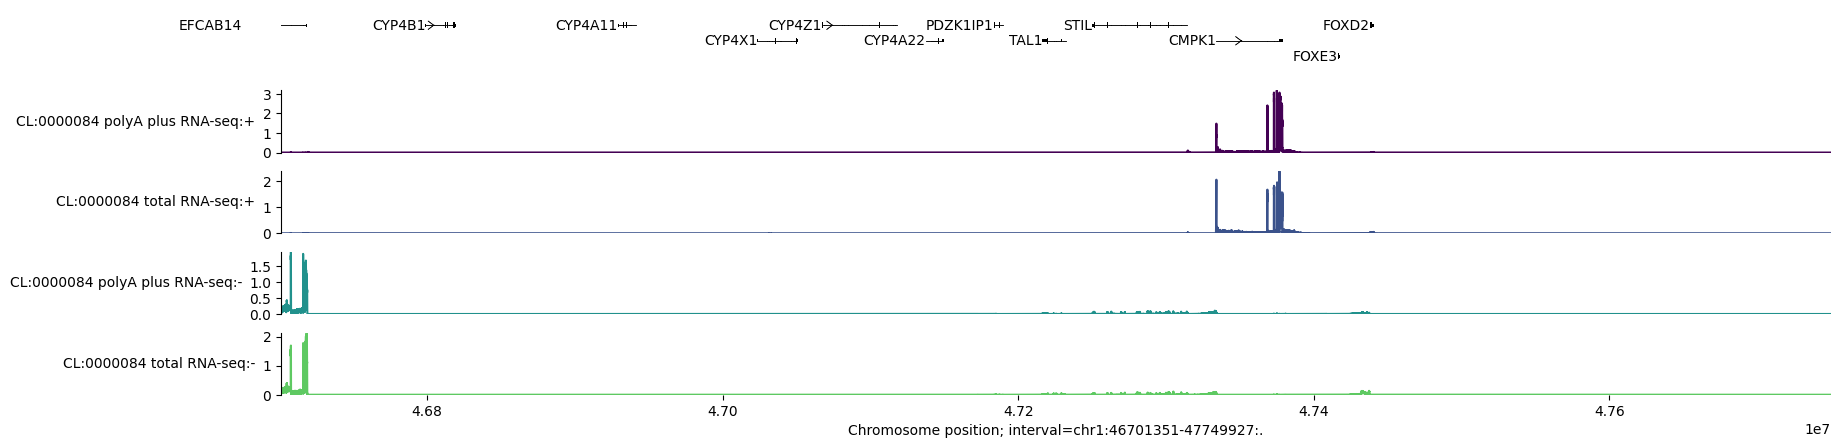

In [42]:
# BB original RNAseq plot code for 1Mb intervall
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(transcripts),
        plot_components.Tracks(output.rna_seq),
    ],
    interval=output.rna_seq.interval,
)

# BB save plot in content
plt.savefig('/content/tal1_rnaseq_1Mb.png', dpi=300, bbox_inches='tight')
plt.show()

This plot visualises the 3 predicted RNA-seq tracks and also marks the location
of the MANE select transcript per gene in the 1MB region.

We can zoom in to the middle of the plot by resizing the interval:

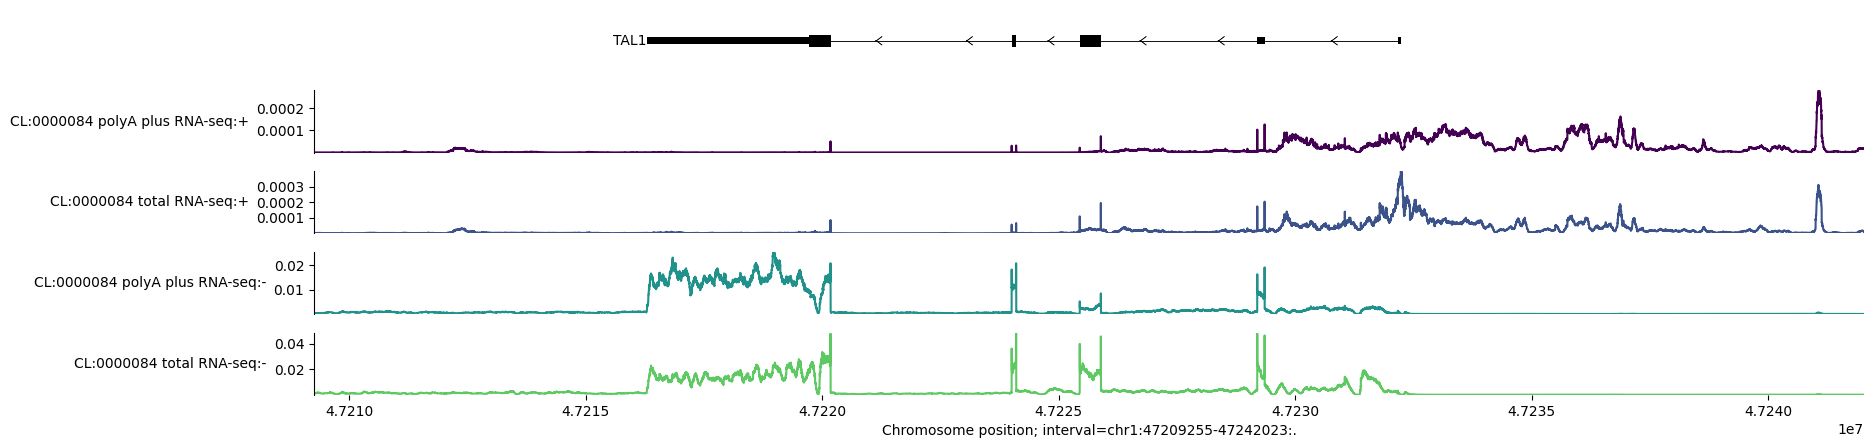

In [13]:
# (BB) original RNAseq plot code for 33Kb TAL1 region
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(
            transcripts, fig_height=0.1
        ),
        plot_components.Tracks(output.rna_seq),
    ],
    interval=output.rna_seq.interval.resize(2**15),
)

# BB save plot in content
plt.savefig('/content/tal1_rnaseq_33Kb.png', dpi=300, bbox_inches='tight')
plt.show()

In [14]:
# BB additional traits and ontology CL.. (TCELL)
output_multi = dna_model.predict_interval(
    interval=interval,
    requested_outputs=[
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.CHIP_HISTONE, # Corrected from HISTONE_MODIFICATIONS
        dna_client.OutputType.CHIP_TF,      # Corrected from TF_BINDING
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.SPLICE_SITE_USAGE,
    ],
    ontology_terms=['CL:0000084'],
)

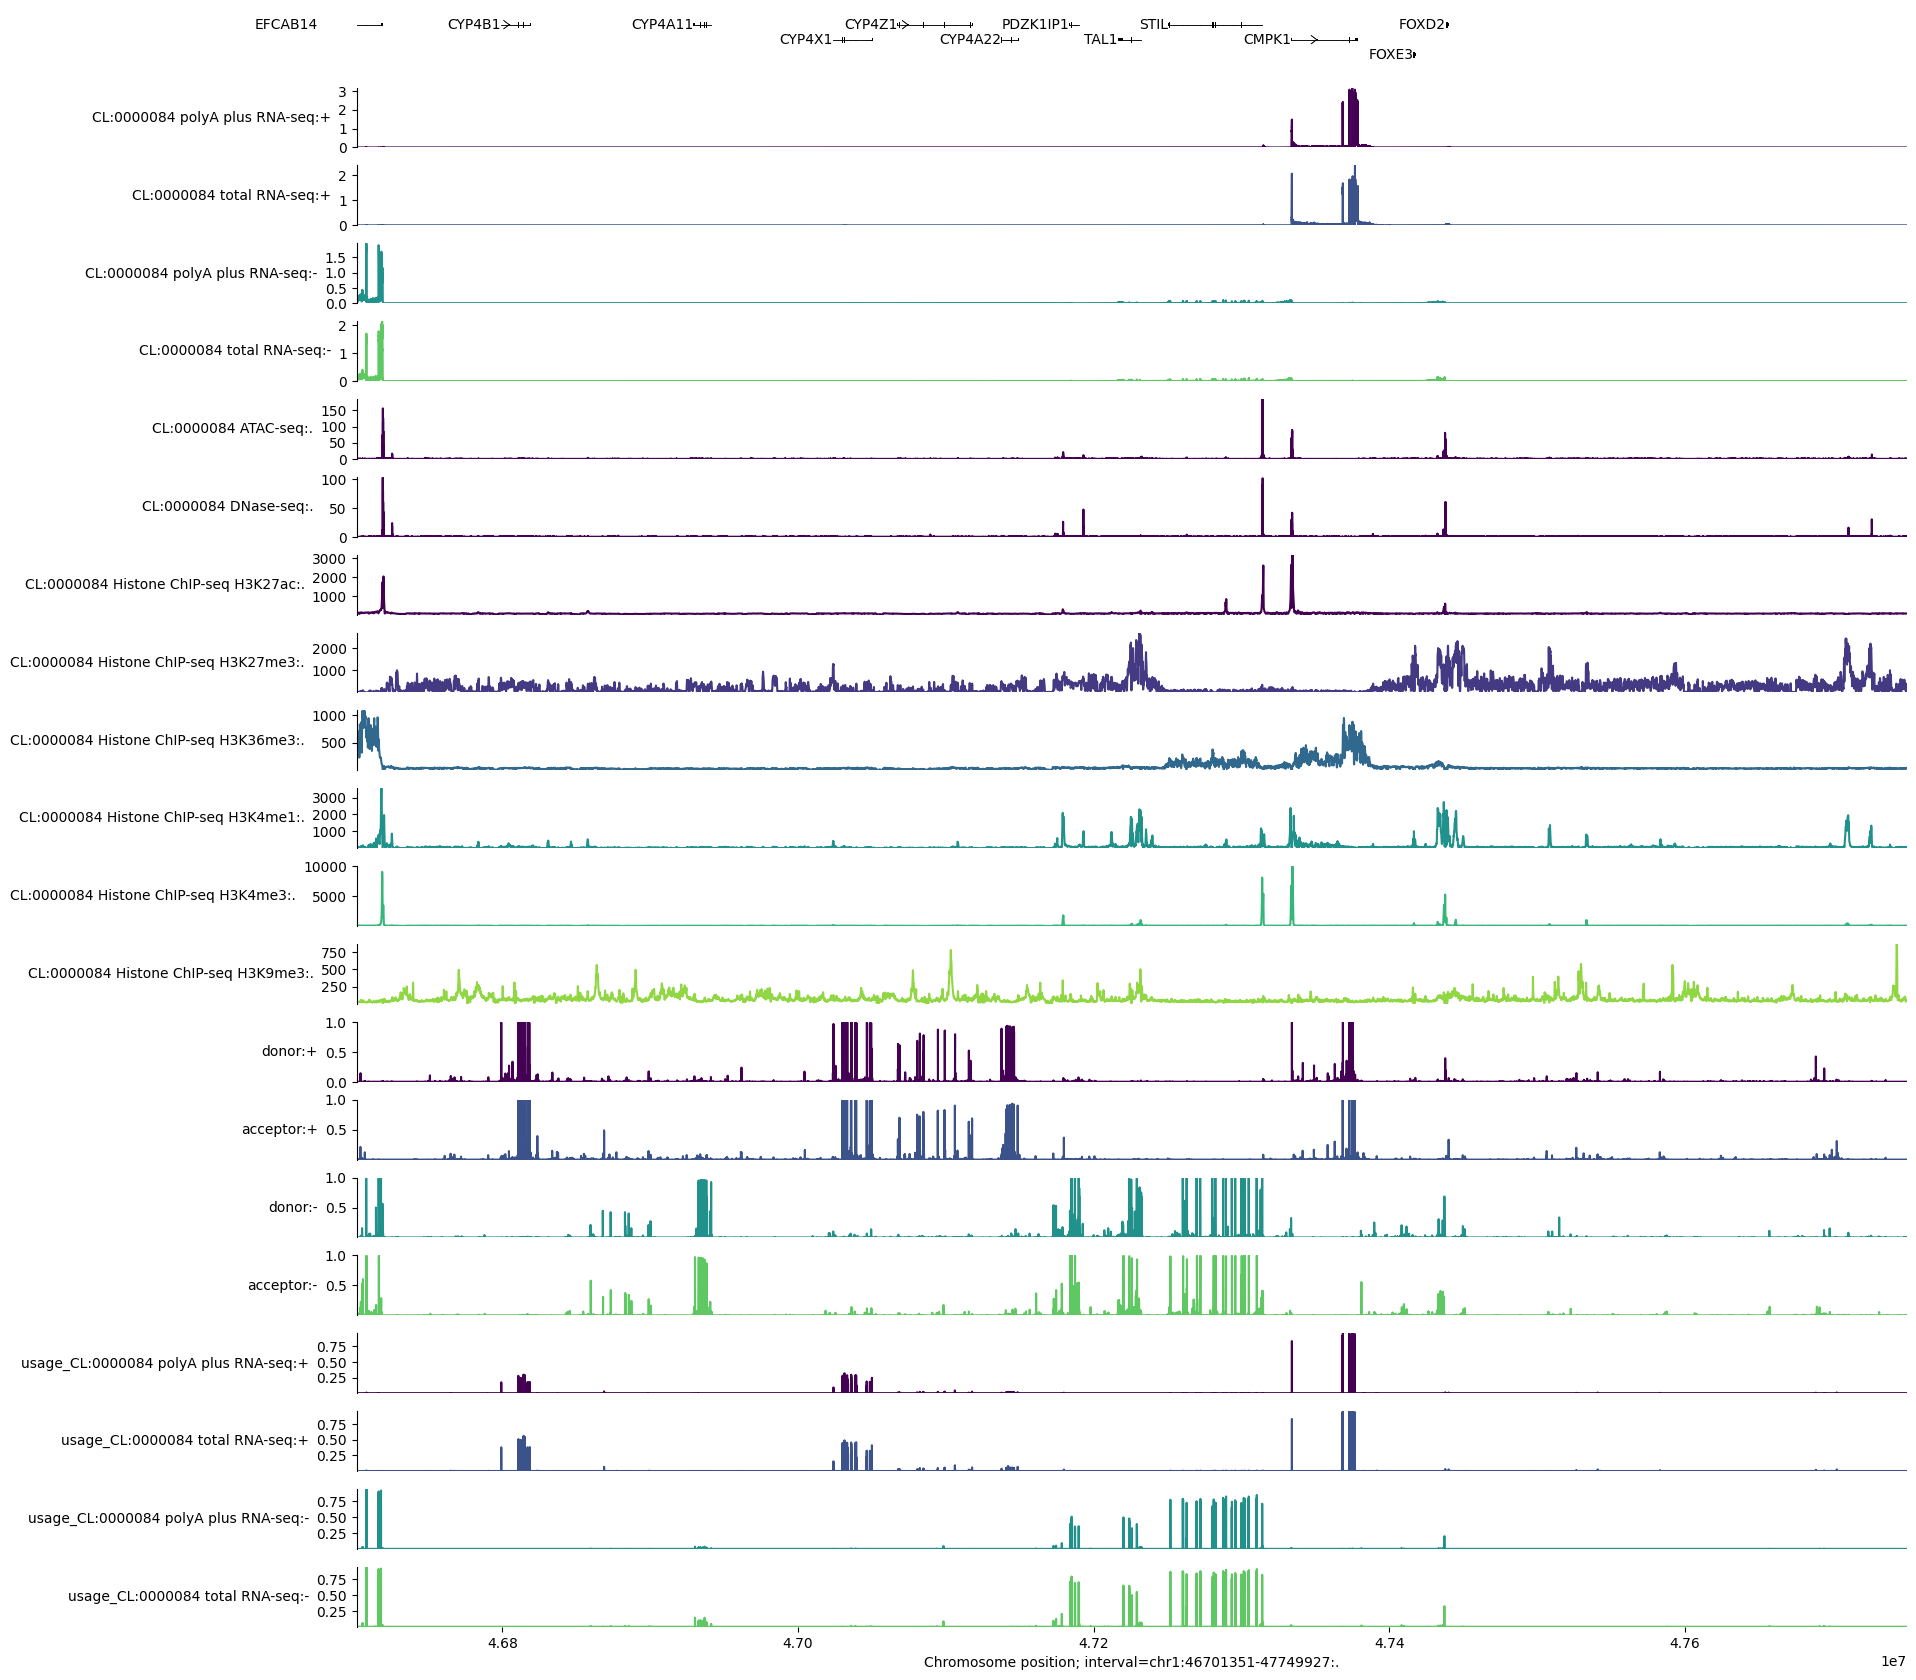

In [15]:
# BB plot additional traits 1Mb
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(
            transcripts,
            fig_height=0.1
        ),
        plot_components.Tracks(output_multi.rna_seq),
        plot_components.Tracks(output_multi.atac),
        plot_components.Tracks(output_multi.dnase),
        plot_components.Tracks(output_multi.chip_histone),
        plot_components.Tracks(output_multi.chip_tf),
        plot_components.Tracks(output_multi.splice_sites),
        plot_components.Tracks(output_multi.splice_site_usage),
    ],
    interval=output_multi.rna_seq.interval,
)

# BB save plot in content
plt.savefig('/content/tal1_addtraits_1Mb.png', dpi=300, bbox_inches='tight')
plt.show()

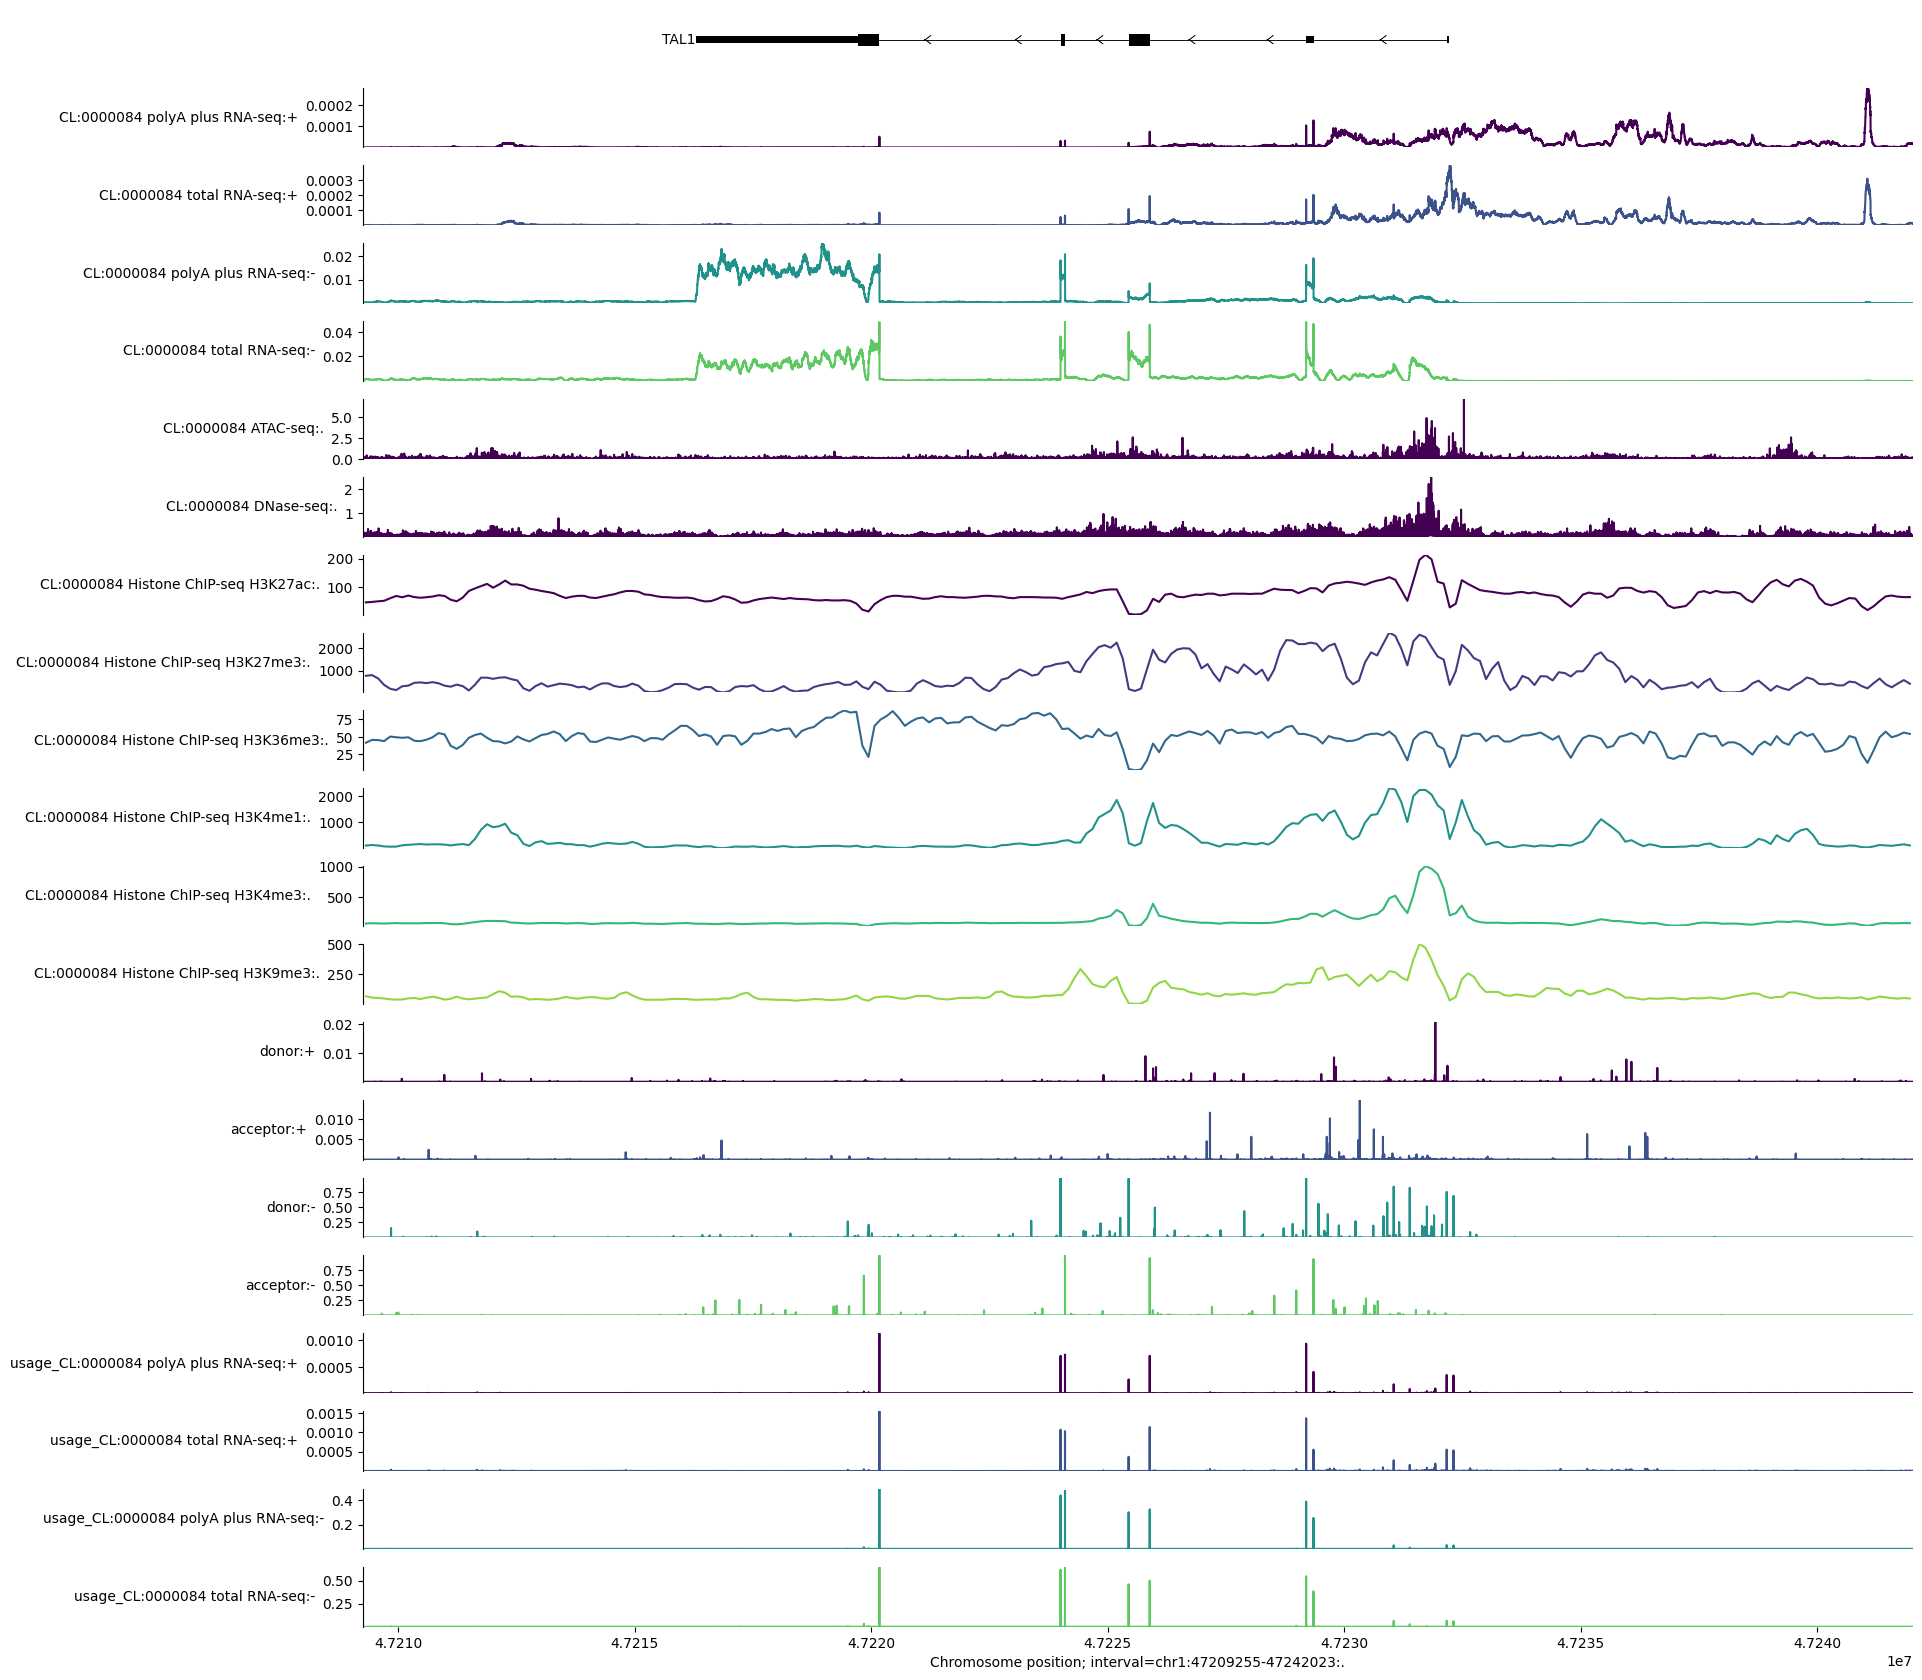

In [43]:
# BB plot additional traits 33Kb
plot_components.plot(
    components=[
        plot_components.TranscriptAnnotation(
            transcripts,
            fig_height=0.1
        ),
        plot_components.Tracks(output_multi.rna_seq),
        plot_components.Tracks(output_multi.atac),
        plot_components.Tracks(output_multi.dnase),
        plot_components.Tracks(output_multi.chip_histone),
        plot_components.Tracks(output_multi.chip_tf),
        plot_components.Tracks(output_multi.splice_sites),
        plot_components.Tracks(output_multi.splice_site_usage),
    ],
    interval=genome.Interval(
        chromosome='chr1',
        start=47209255,
        end=47242023,
        strand='.'
    ),
)

# BB save plot in content
plt.savefig('/content/tal1_addtraits_33Kb.png', dpi=300, bbox_inches='tight')
plt.show()

You can see here that predicted RNA-seq values are nicely aligned with the
location of exons, and that the predictions are stranded – the predicted values
are much higher for the positive strand, where the gene is located. We see that
the *CYP2B6* gene is on the positive strand since the arrows in the transcript
go from left to right.

For more detail on the visualization library, please refer to the
[visualization basics guide](https://www.alphagenomedocs.com/visualization_library_basics.html)
and
[library documentation](https://www.alphagenomedocs.com/api/visualization.html).

## Predict variant effects

We can predict the effect of a variant on a specific output type and tissue by
making predictions for the reference (REF) and alternative (ALT) allele
sequences.

We specify the variant by defining a `genome.Variant` object. The specific
variant below is a known variant affecting gene expression in colon tissue:

In [44]:
# BB replacement of TAL1p (Biomni annot.) with CMVmin
variant = genome.Variant(
    chromosome='chr1',
    position=47232336,
    reference_bases='gaggcgcgccggggccgtgtgcgccgcagagataaggcactgccgcgggtccgcccgcccccgataagcgcctcggccattatgggccaaatgattcattttaatttggcaatttcaccggagggagtggggactggttgagcggcgctaggaccggctccggaacgcgctgcggggagcgttggacgcgctgtctaggacccagcagatccagcccccatctctaatcccaaggcctctcaggaaccccagcttcccacaacctcagtcccttaacctttcagacacctttcttcagcgactctcaccccagcactctgtccctacctctgaagaccaccatgataccaaaatcgtcacctcccagggcttctttcttattcttcctccagtgtcccagacacccagatttcaatgggcagtctccctatcccagaaagctccccagcccttccctacctcttcacccccttctaaaatagagccggtaactcaaatcc',
    alternate_bases='GGCTGGATCGGTCCCGGTGTCTTCTATGGAGGTCAAAACAGCGTGGATGGCGTCTCCAGGCGATCTGACGGTTCACTAAACGAGCTCTGCTTATATAGGCCTCCCACCGTACACGCCTACTCGACCCGGGTACCG',
)

ValueError: Invalid reference bases: "gaggcgcgccggggccgtgtgcgccgcagagataaggcactgccgcgggtccgcccgcccccgataagcgcctcggccattatgggccaaatgattcattttaatttggcaatttcaccggagggagtggggactggttgagcggcgctaggaccggctccggaacgcgctgcggggagcgttggacgcgctgtctaggacccagcagatccagcccccatctctaatcccaaggcctctcaggaaccccagcttcccacaacctcagtcccttaacctttcagacacctttcttcagcgactctcaccccagcactctgtccctacctctgaagaccaccatgataccaaaatcgtcacctcccagggcttctttcttattcttcctccagtgtcccagacacccagatttcaatgggcagtctccctatcccagaaagctccccagcccttccctacctcttcacccccttctaaaatagagccggtaactcaaatcc". Must only contain "ACGTN".

Next, we define the interval over which to make the REF and ALT predictions. A
quick way to get a `genome.Interval` from a `genome.Variant` is by calling
`.reference_interval`, which we can resize to a model-compatible sequence
length:

In [31]:
interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

We then use `predict_variant` to get the REF and ALT RNA-seq predictions in the
interval for "Colon - Transverse" tissue (`UBERON:0001157`):

In [32]:
# BB additional traits for variant effect predictions in 1Mb interval
variant_output_multi = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[
        dna_client.OutputType.RNA_SEQ,
        dna_client.OutputType.ATAC,
        dna_client.OutputType.DNASE,
        dna_client.OutputType.CHIP_HISTONE,
        dna_client.OutputType.CHIP_TF,
        dna_client.OutputType.SPLICE_SITES,
        dna_client.OutputType.SPLICE_JUNCTIONS,
        dna_client.OutputType.SPLICE_SITE_USAGE,
    ],
    ontology_terms=['CL:0000084'],
)

We can plot the predicted REF and ALT values as a single plot and zoom in on the
affected gene to better visualise the variant's effect on gene expression:

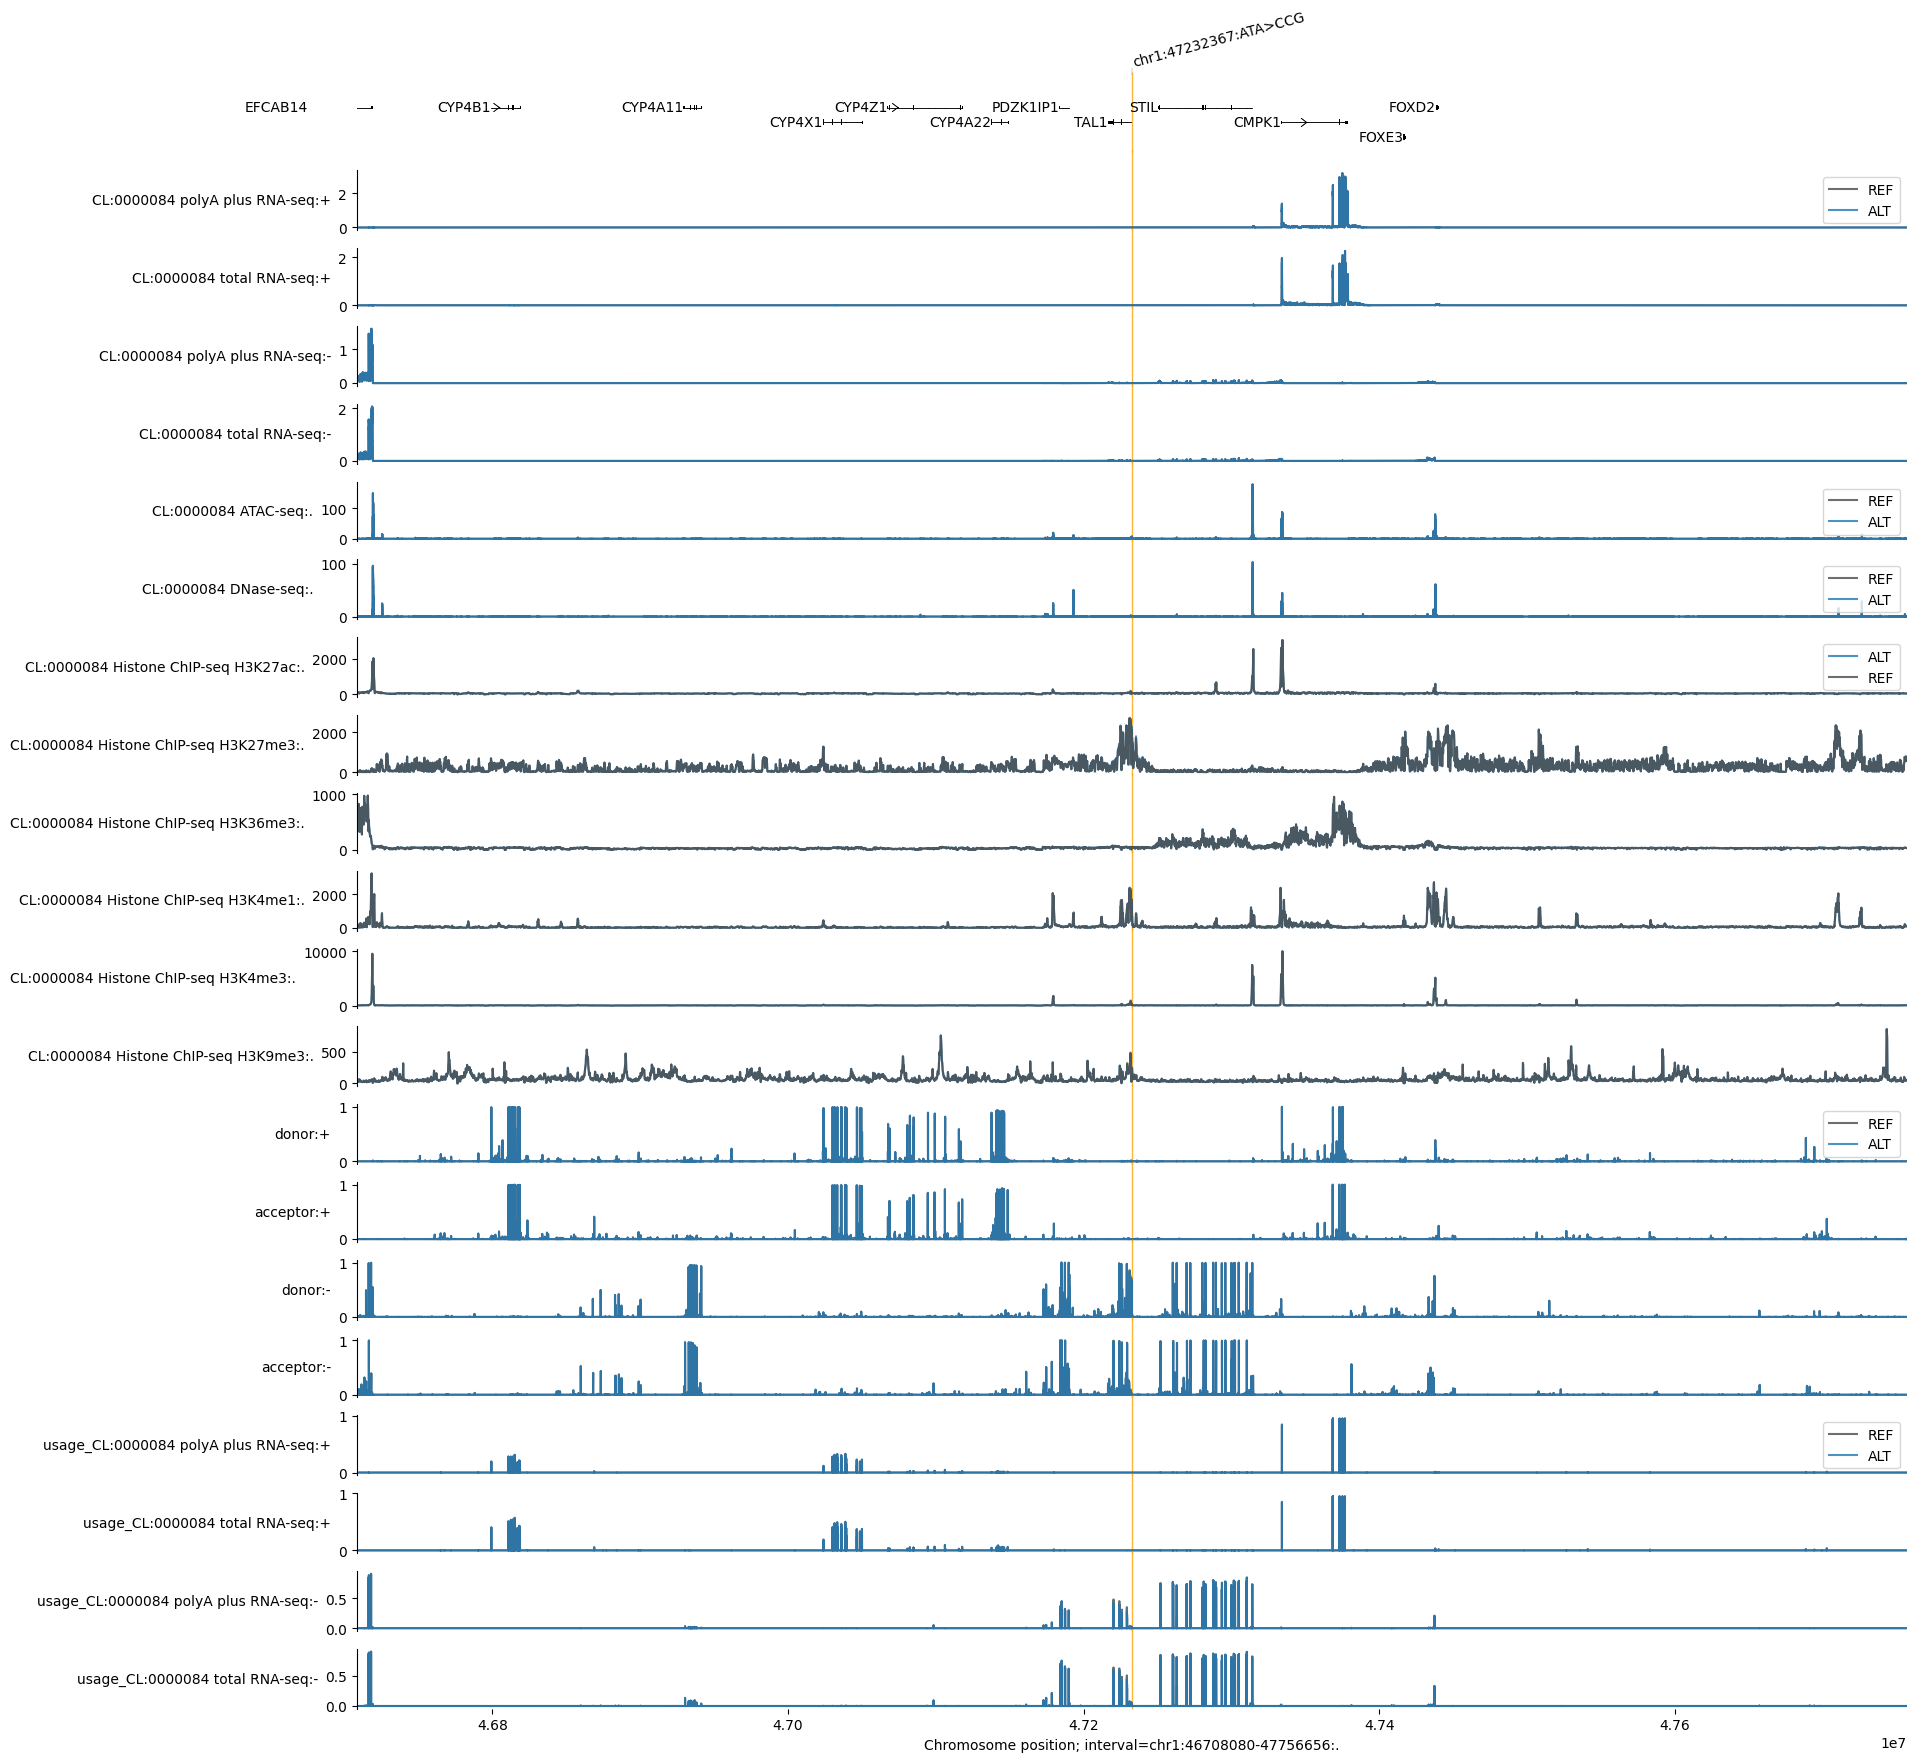

In [34]:
# BB plot REF vs ALT for multiple traits in the full 1 Mb interval
transcripts = transcript_extractor.extract(interval)

ref_color = '#4a4a4a'   # dark grey
alt_color = '#1f77b4'   # blue

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.1),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.rna_seq,
                'ALT': variant_output_multi.alternate.rna_seq,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.atac,
                'ALT': variant_output_multi.alternate.atac,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.dnase,
                'ALT': variant_output_multi.alternate.dnase,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.chip_histone,
                'ALT': variant_output_multi.alternate.chip_histone,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.chip_tf,
                'ALT': variant_output_multi.alternate.chip_tf,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.splice_sites,
                'ALT': variant_output_multi.alternate.splice_sites,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.splice_site_usage,
                'ALT': variant_output_multi.alternate.splice_site_usage,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),
    ],
    interval=variant_output_multi.reference.rna_seq.interval,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)

plt.savefig('/content/tal1_mutGATA_effects_alltraits_1Mb_bluegrey.png', dpi=300, bbox_inches='tight')
plt.show()

In [35]:
# BB define 33 kb TAL1 region for variant-effect plotting
tal1_interval_33kb = genome.Interval(
    chromosome='chr1',
    start=47209255,
    end=47242023,
    strand='.'
)

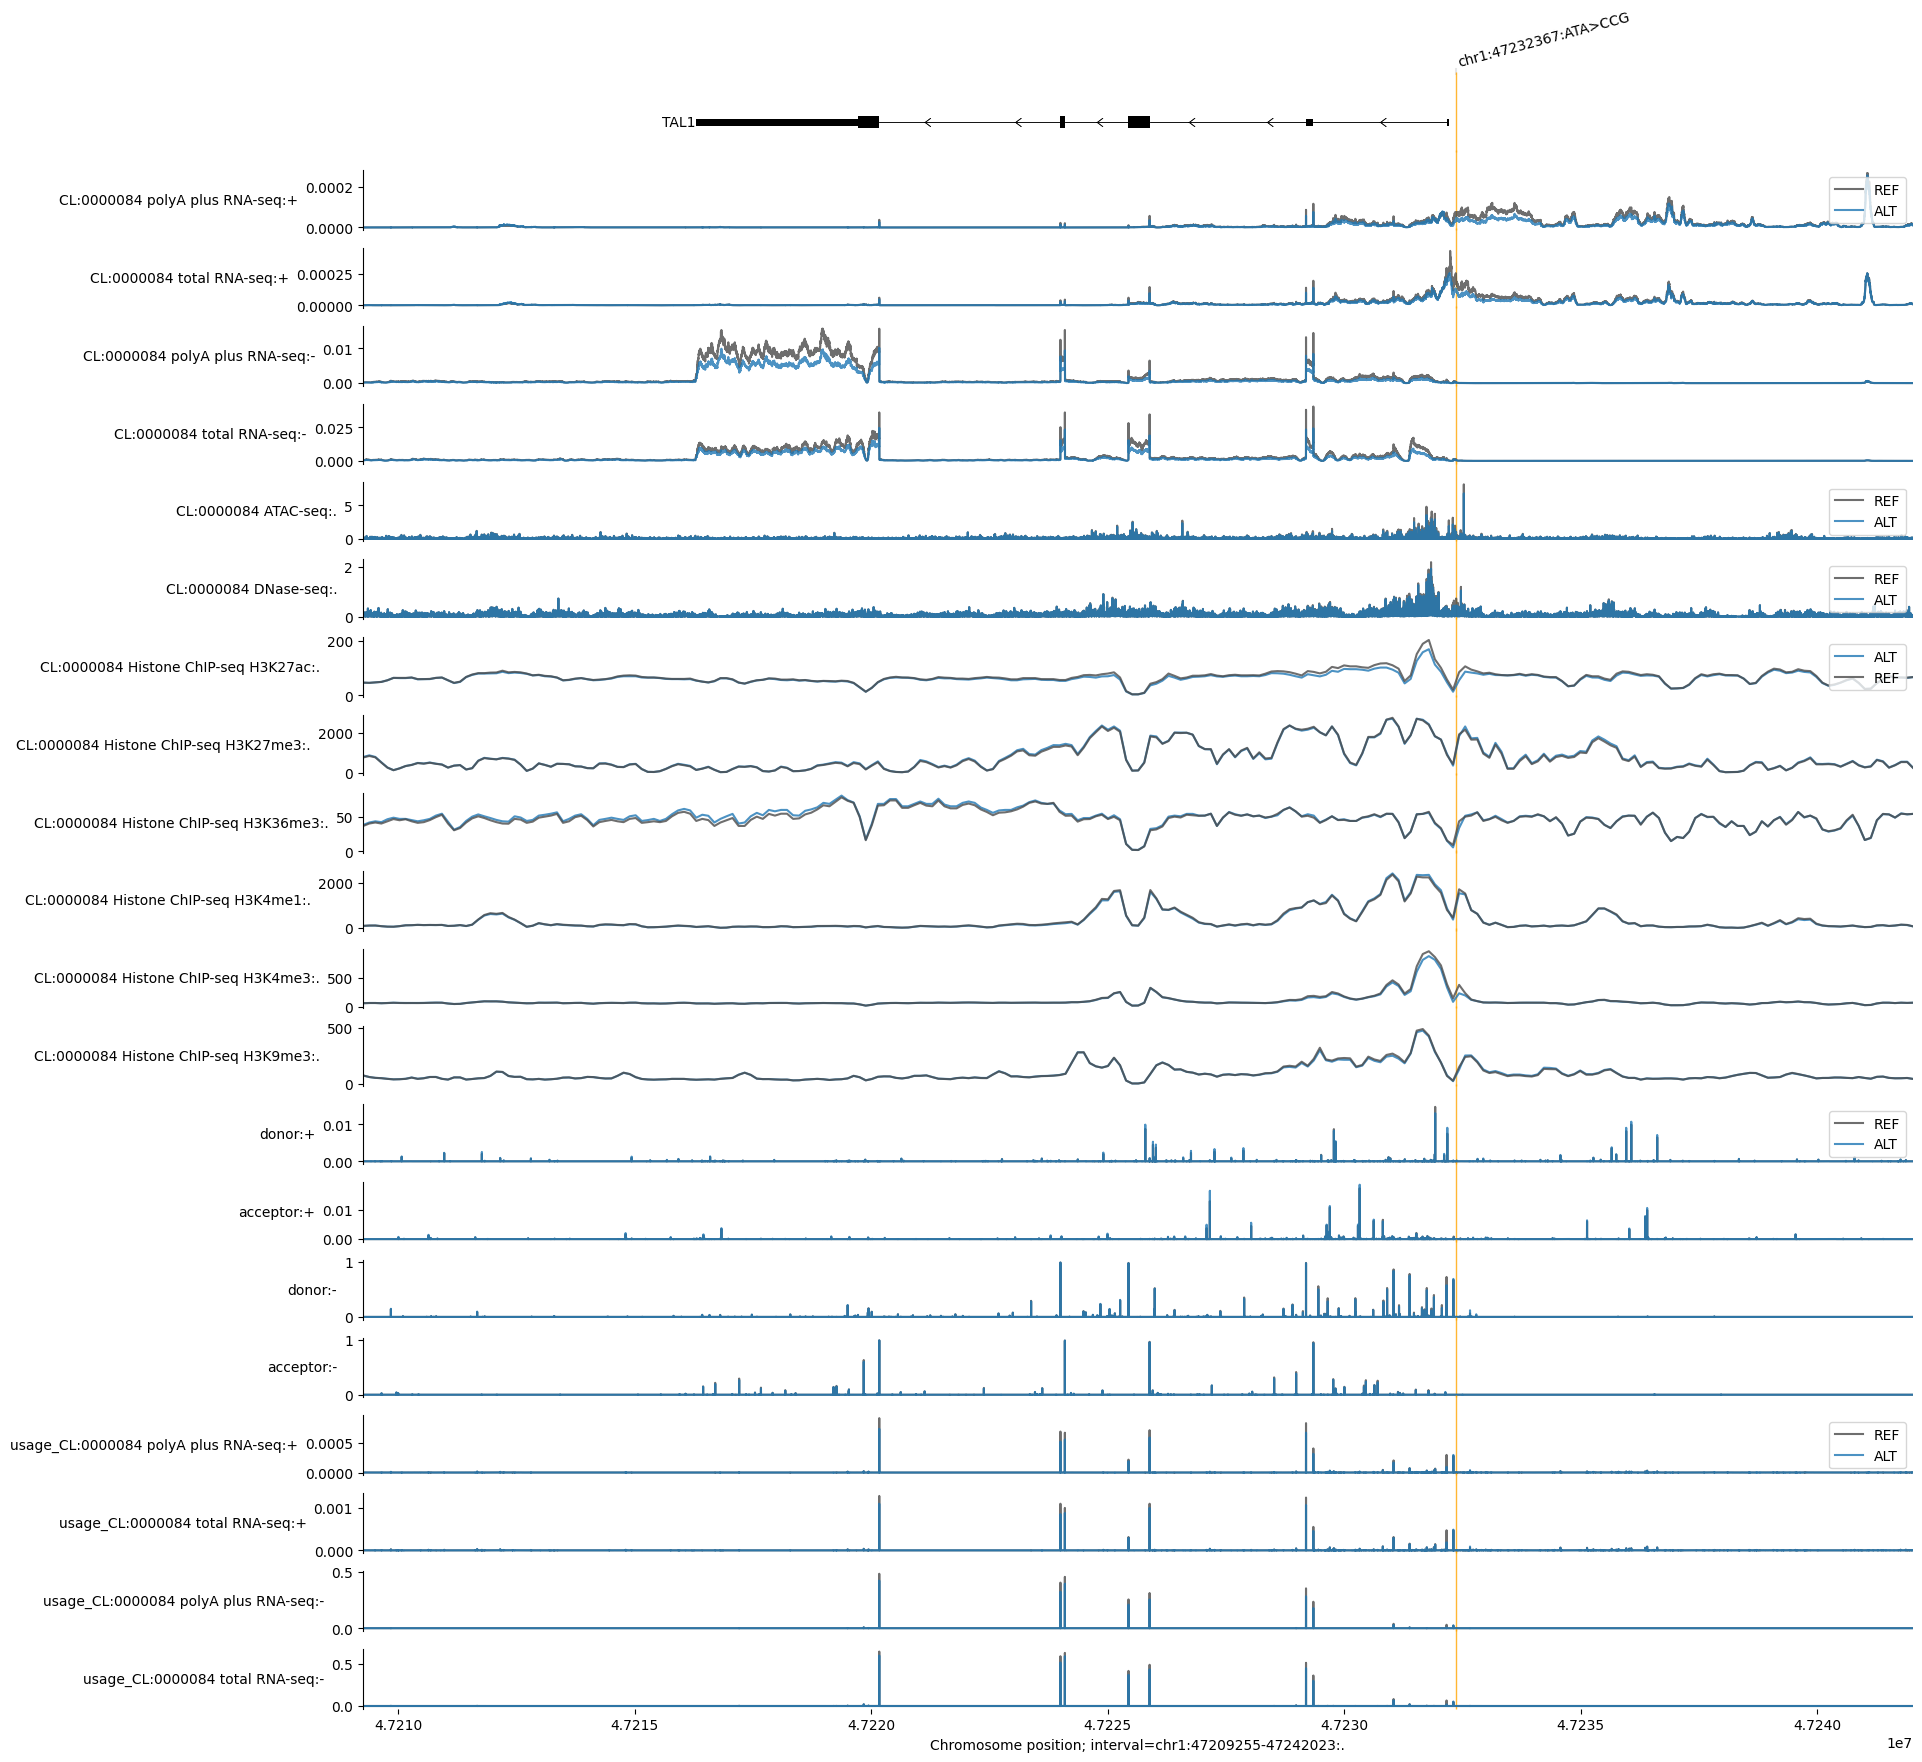

In [36]:
# BB plot REF vs ALT for multiple traits in the 33 kb TAL1 region
transcripts_33kb = transcript_extractor.extract(tal1_interval_33kb)

ref_color = '#4a4a4a'   # dark grey
alt_color = '#1f77b4'   # blue

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts_33kb, fig_height=0.1),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.rna_seq,
                'ALT': variant_output_multi.alternate.rna_seq,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.atac,
                'ALT': variant_output_multi.alternate.atac,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.dnase,
                'ALT': variant_output_multi.alternate.dnase,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.chip_histone,
                'ALT': variant_output_multi.alternate.chip_histone,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.chip_tf,
                'ALT': variant_output_multi.alternate.chip_tf,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.splice_sites,
                'ALT': variant_output_multi.alternate.splice_sites,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),

        plot_components.OverlaidTracks(
            tdata={
                'REF': variant_output_multi.reference.splice_site_usage,
                'ALT': variant_output_multi.alternate.splice_site_usage,
            },
            colors={'REF': ref_color, 'ALT': alt_color},
        ),
    ],
    interval=tal1_interval_33kb,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)

plt.savefig('/content/tal1_mutGATA_effects_alltraits_33kb_bluegrey.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
# BB helper to convert REF/ALT tracks into ALT-REF difference tracks
import copy
import numpy as np

def delta_track(ref_track, alt_track):
    out = copy.deepcopy(alt_track)
    out.values = np.asarray(alt_track.values) - np.asarray(ref_track.values)
    return out

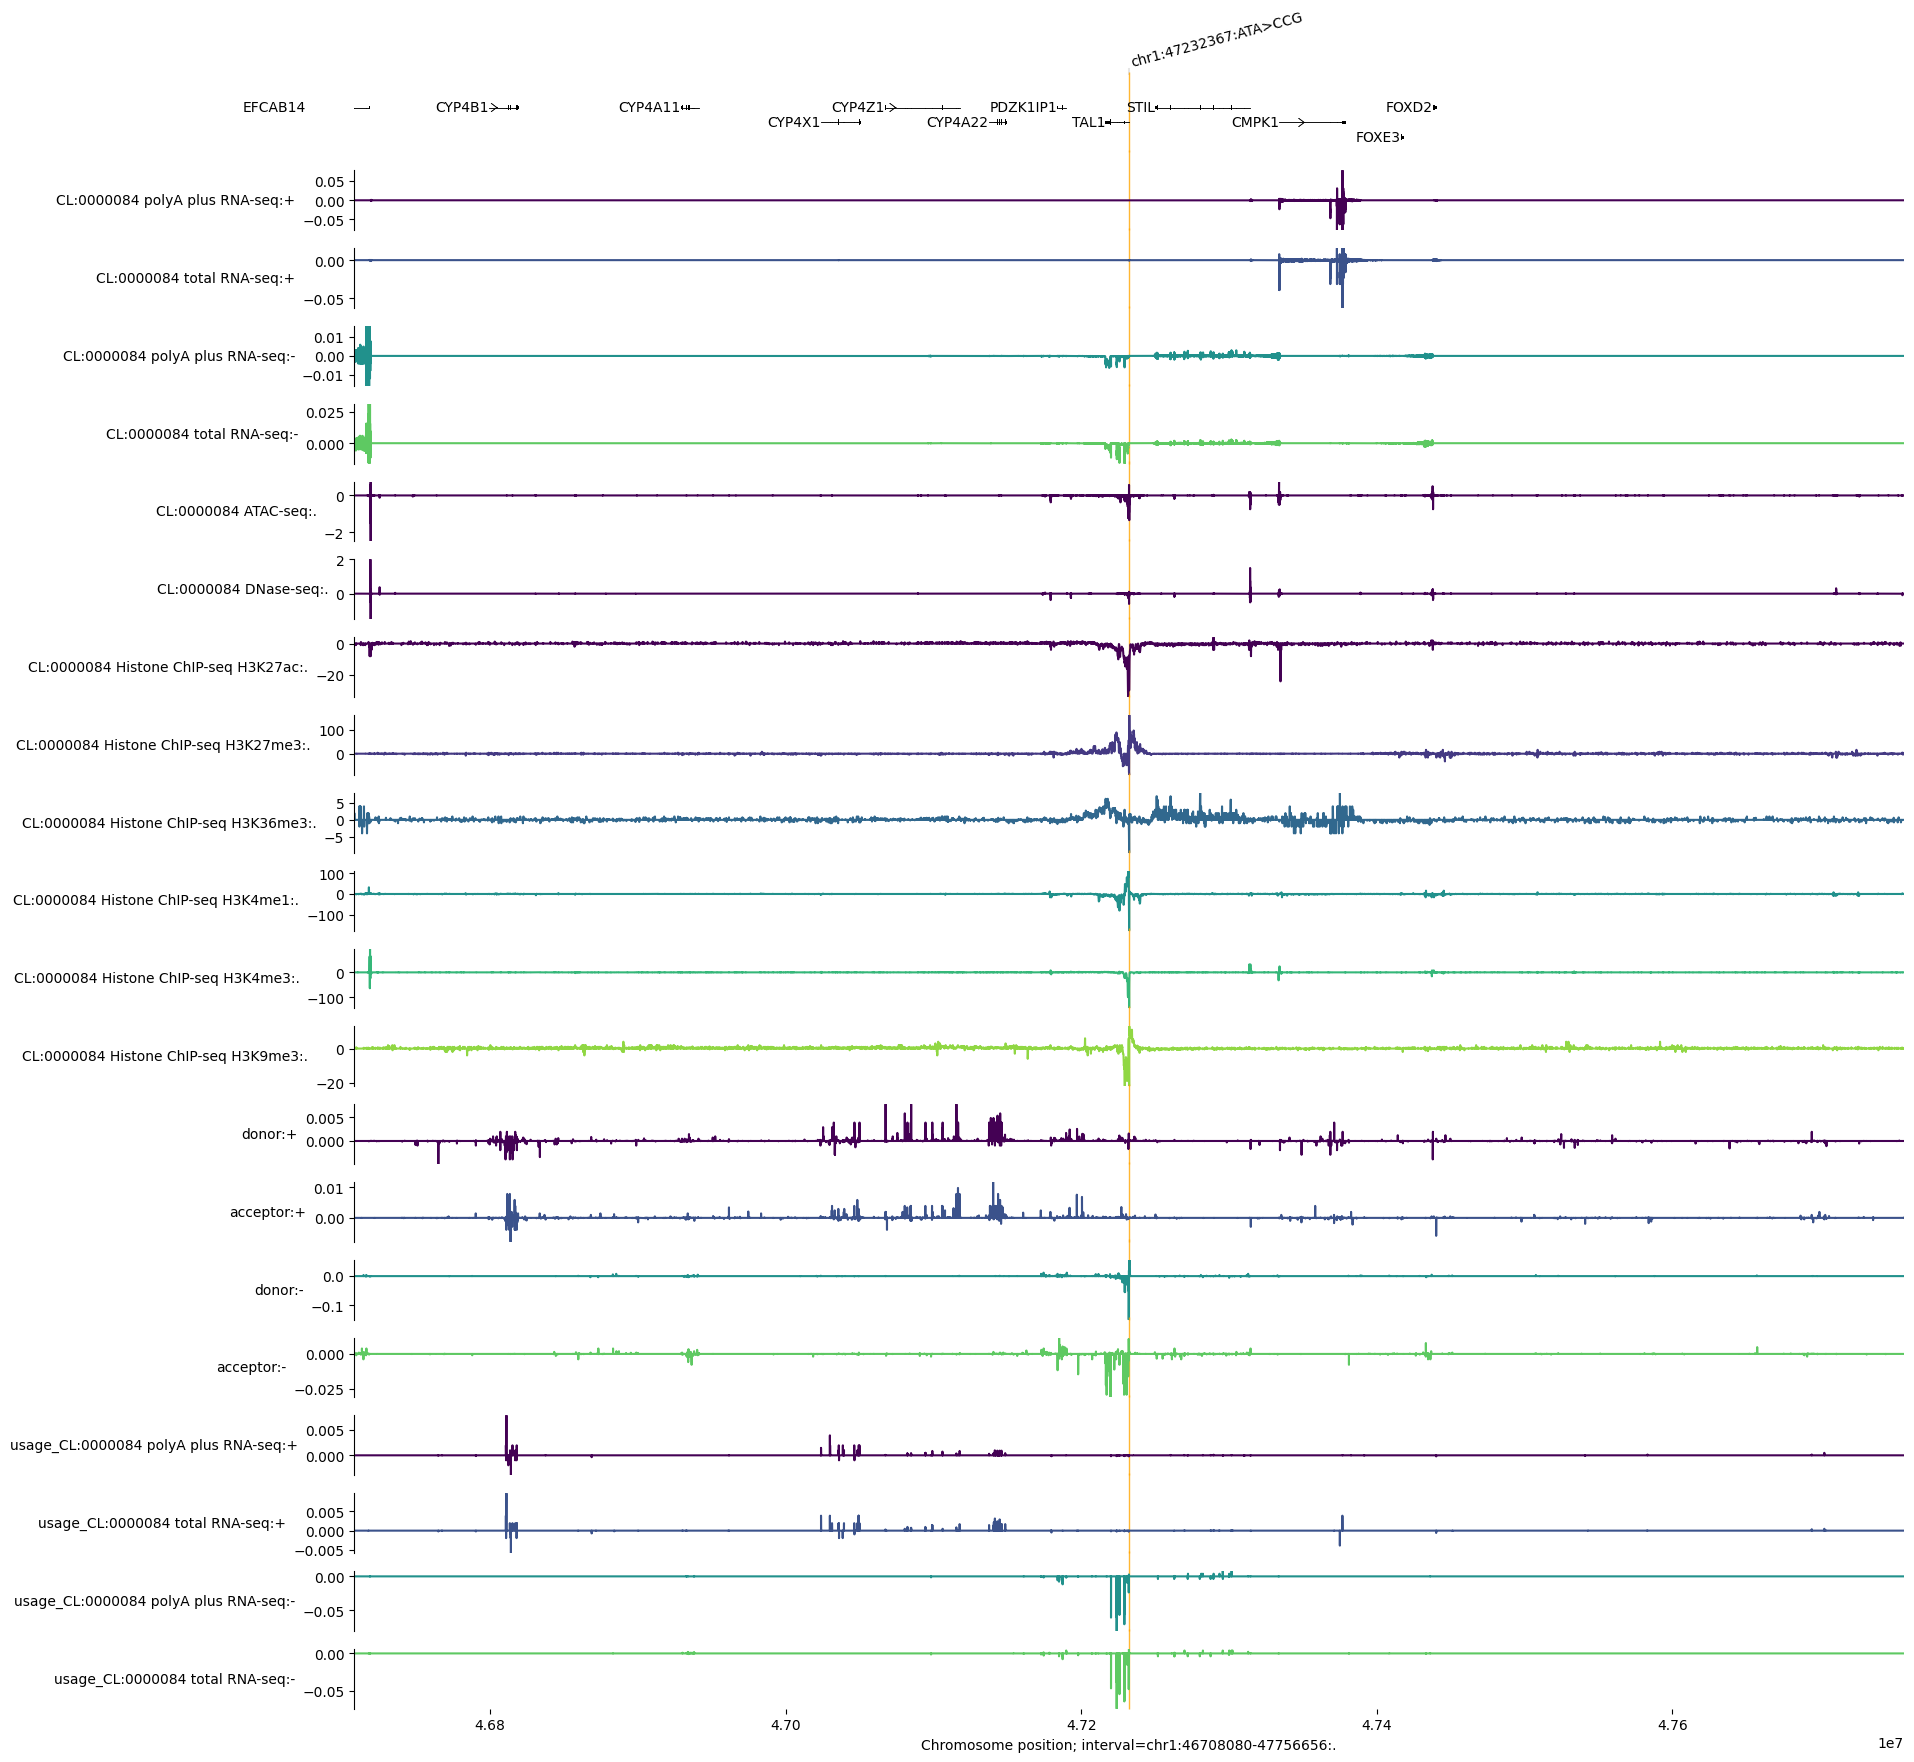

In [38]:
import copy
import numpy as np
from alphagenome.data.track_data import TrackData # Import TrackData class

def delta_track(ref_track, alt_track):
    delta_values = np.asarray(alt_track.values) - np.asarray(ref_track.values)
    # Create a new TrackData object with the delta values, including the resolution.
    return TrackData(
        values=delta_values,
        metadata=alt_track.metadata,
        interval=alt_track.interval,
        resolution=alt_track.resolution
    )

# BB plot ALT-REF differences for multiple traits in the full 1 Mb interval
transcripts = transcript_extractor.extract(interval)

delta_rna = delta_track(variant_output_multi.reference.rna_seq, variant_output_multi.alternate.rna_seq)
delta_atac = delta_track(variant_output_multi.reference.atac, variant_output_multi.alternate.atac)
delta_dnase = delta_track(variant_output_multi.reference.dnase, variant_output_multi.alternate.dnase)
delta_chip_histone = delta_track(variant_output_multi.reference.chip_histone, variant_output_multi.alternate.chip_histone)
delta_chip_tf = delta_track(variant_output_multi.reference.chip_tf, variant_output_multi.alternate.chip_tf)
delta_splice_sites = delta_track(variant_output_multi.reference.splice_sites, variant_output_multi.alternate.splice_sites)
delta_splice_site_usage = delta_track(variant_output_multi.reference.splice_site_usage, variant_output_multi.alternate.splice_site_usage)

plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts, fig_height=0.1),
        plot_components.Tracks(delta_rna),
        plot_components.Tracks(delta_atac),
        plot_components.Tracks(delta_dnase),
        plot_components.Tracks(delta_chip_histone),
        plot_components.Tracks(delta_chip_tf),
        plot_components.Tracks(delta_splice_sites),
        plot_components.Tracks(delta_splice_site_usage),
    ],
    interval=variant_output_multi.reference.rna_seq.interval,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)

plt.savefig('/content/tal1_mutGATA_effects_delta_alltraits_1Mb.png', dpi=300, bbox_inches='tight')
plt.show()

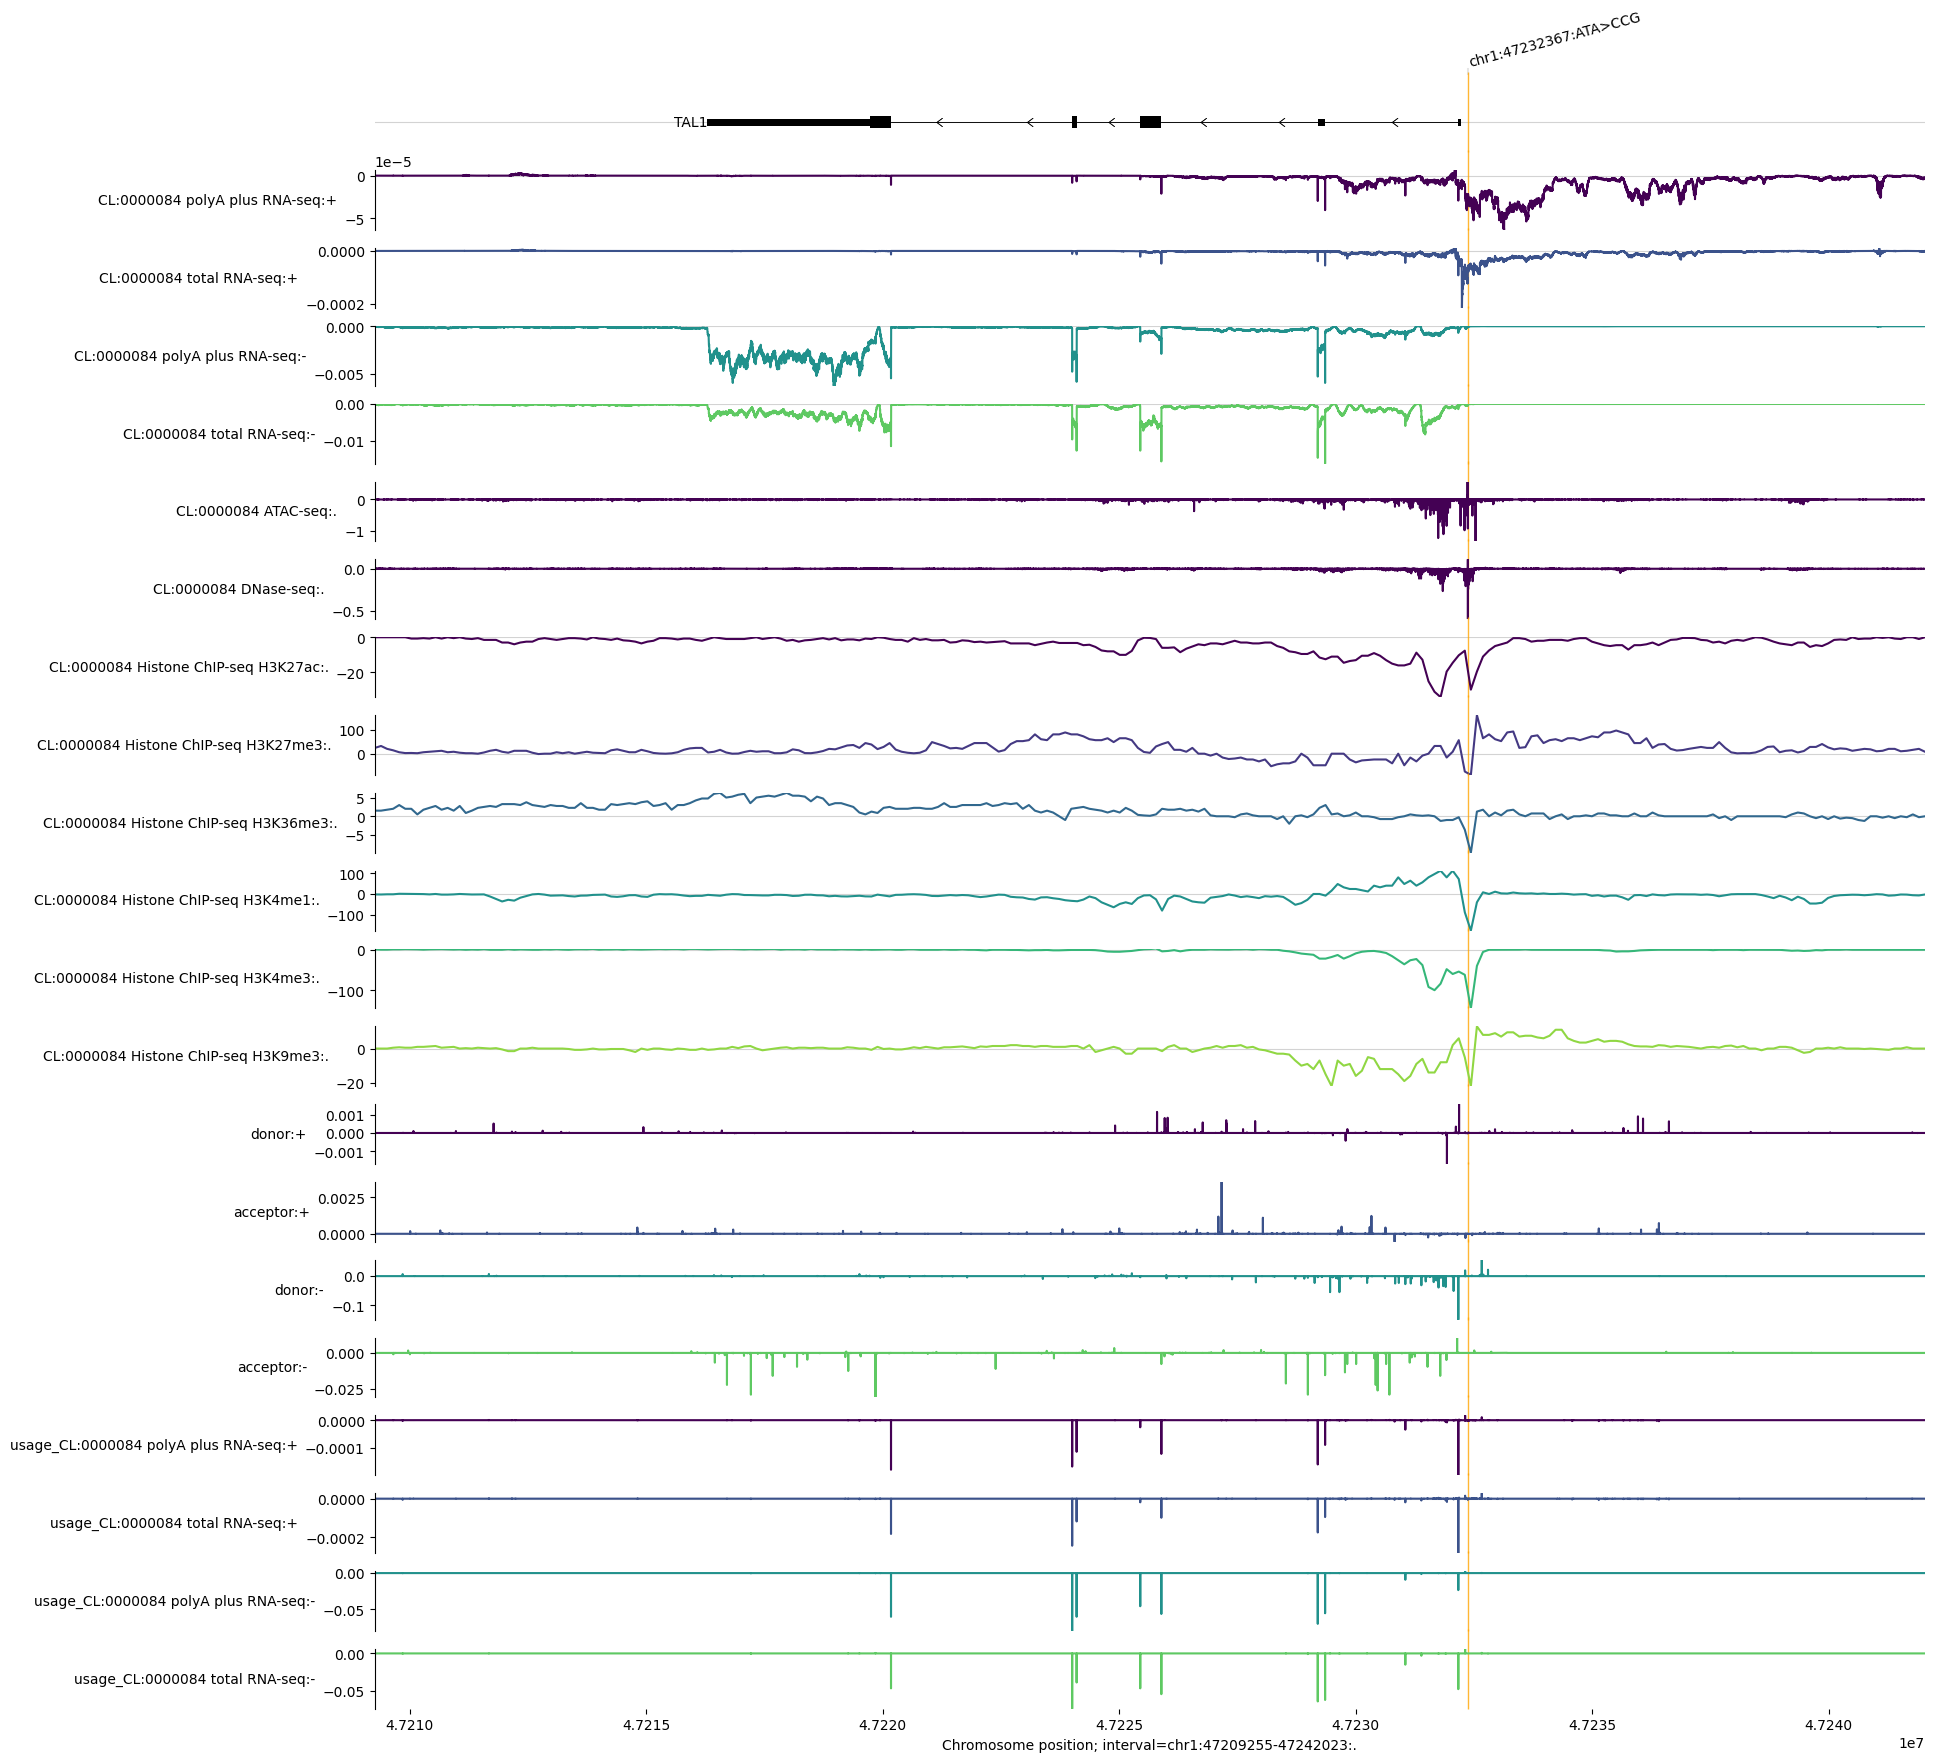

In [39]:
# BB plot ALT-REF differences for multiple traits in the 33 kb TAL1 interval
tal1_interval_33kb = genome.Interval(
    chromosome='chr1',
    start=47209255,
    end=47242023,
    strand='.'
)

transcripts_33kb = transcript_extractor.extract(tal1_interval_33kb)

fig = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts_33kb, fig_height=0.1),
        plot_components.Tracks(delta_rna),
        plot_components.Tracks(delta_atac),
        plot_components.Tracks(delta_dnase),
        plot_components.Tracks(delta_chip_histone),
        plot_components.Tracks(delta_chip_tf),
        plot_components.Tracks(delta_splice_sites),
        plot_components.Tracks(delta_splice_site_usage),
    ],
    interval=tal1_interval_33kb,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)

# BB: add light grey zero line to every signal track
for ax in fig.axes[1:]:   # skip transcript annotation track, access axes from fig object
    ax.axhline(0, color='lightgrey', linewidth=0.8, zorder=0)

plt.savefig('/content/tal1_mutGATA_effects_delta_alltraits_33kb_zeroline.png',
            dpi=300, bbox_inches='tight')
plt.show()

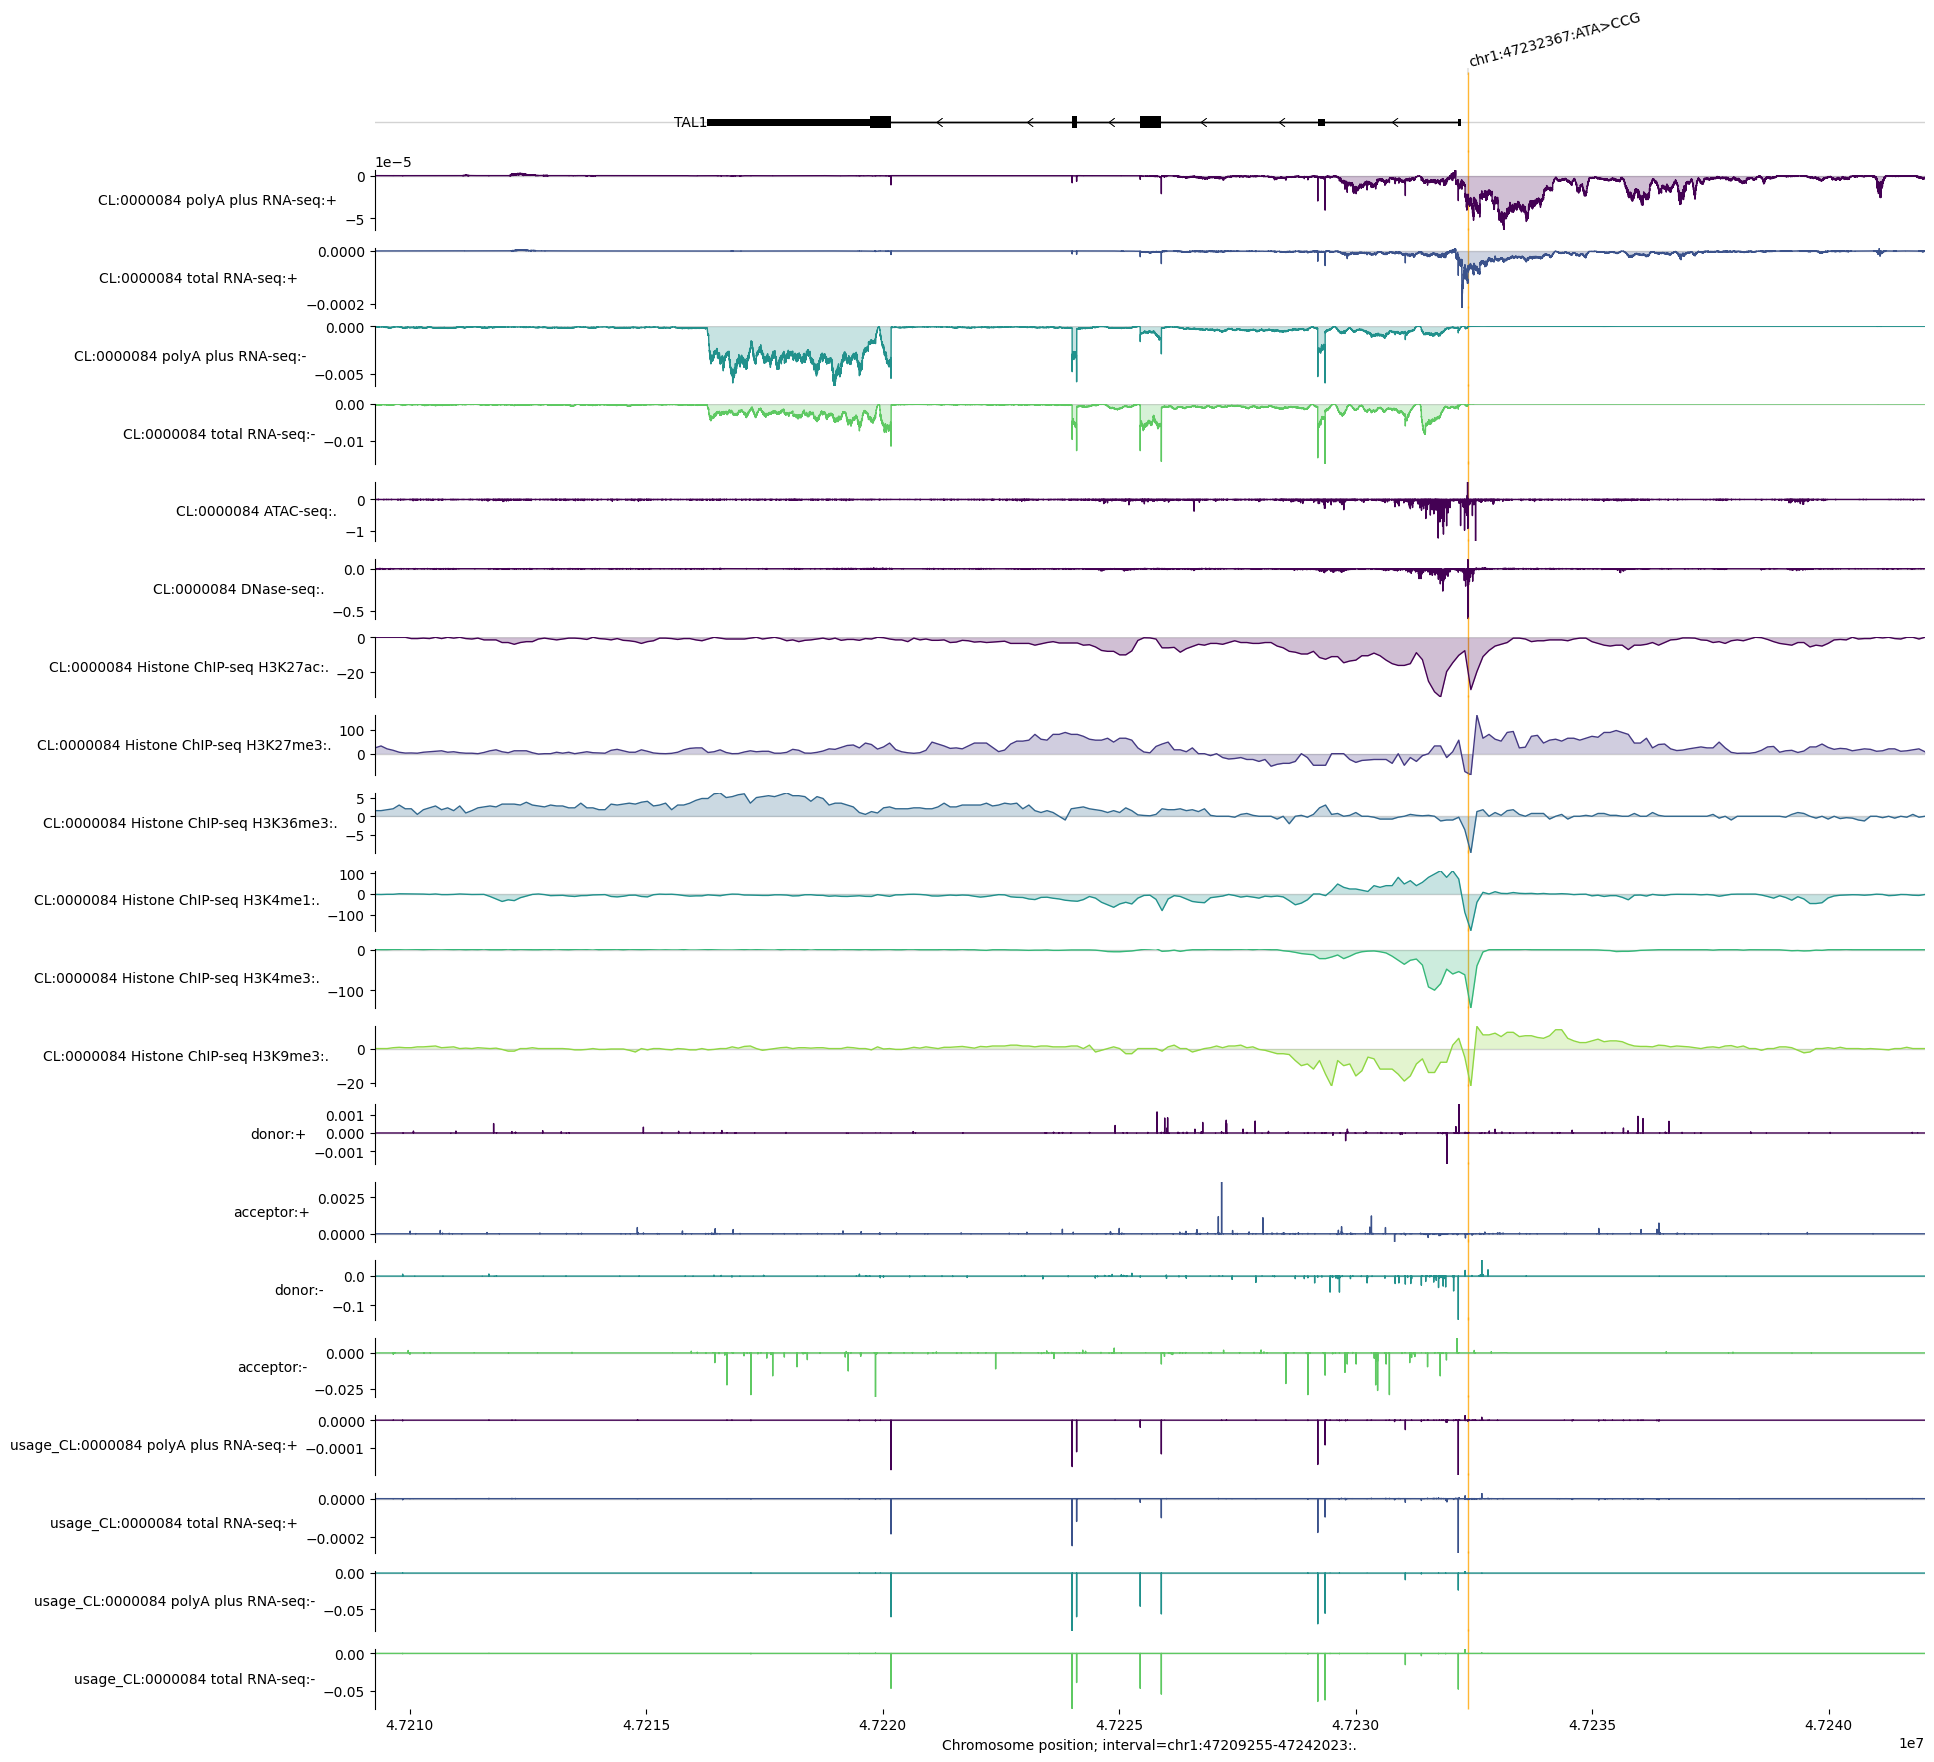

In [40]:
# BB 33 kb TAL1 interval, fill only the area between plotted ALT-REF signal and zero line

import numpy as np

tal1_interval_33kb = genome.Interval(
    chromosome='chr1',
    start=47209255,
    end=47242023,
    strand='.'
)

transcripts_33kb = transcript_extractor.extract(tal1_interval_33kb)

# Delta tracks (ALT - REF)
delta_rna = delta_track(variant_output_multi.reference.rna_seq, variant_output_multi.alternate.rna_seq)
delta_atac = delta_track(variant_output_multi.reference.atac, variant_output_multi.alternate.atac)
delta_dnase = delta_track(variant_output_multi.reference.dnase, variant_output_multi.alternate.dnase)
delta_chip_histone = delta_track(variant_output_multi.reference.chip_histone, variant_output_multi.alternate.chip_histone)
delta_chip_tf = delta_track(variant_output_multi.reference.chip_tf, variant_output_multi.alternate.chip_tf)
delta_splice_sites = delta_track(variant_output_multi.reference.splice_sites, variant_output_multi.alternate.splice_sites)
delta_splice_site_usage = delta_track(variant_output_multi.reference.splice_site_usage, variant_output_multi.alternate.splice_site_usage)

fig = plot_components.plot(
    [
        plot_components.TranscriptAnnotation(transcripts_33kb, fig_height=0.1),
        plot_components.Tracks(delta_rna),
        plot_components.Tracks(delta_atac),
        plot_components.Tracks(delta_dnase),
        plot_components.Tracks(delta_chip_histone),
        plot_components.Tracks(delta_chip_tf),
        plot_components.Tracks(delta_splice_sites),
        plot_components.Tracks(delta_splice_site_usage),
    ],
    interval=tal1_interval_33kb,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)

# Skip transcript annotation axis; process only signal axes
for ax in fig.axes[1:]:
    # light grey zero line
    ax.axhline(0, color='lightgrey', linewidth=0.8, zorder=0)

    # fill exactly under each plotted line
    for line in ax.lines:
        x = np.asarray(line.get_xdata())
        y = np.asarray(line.get_ydata())
        color = line.get_color()

        # keep line visible
        line.set_linewidth(1.0)

        # fill only between signal and zero
        ax.fill_between(
            x, 0, y,
            color=color,
            alpha=0.25,
            linewidth=0,
            zorder=line.get_zorder() - 1
        )

plt.savefig(
    '/content/tal1_mutGATA_effects_delta_filledclean_33kb_v2.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

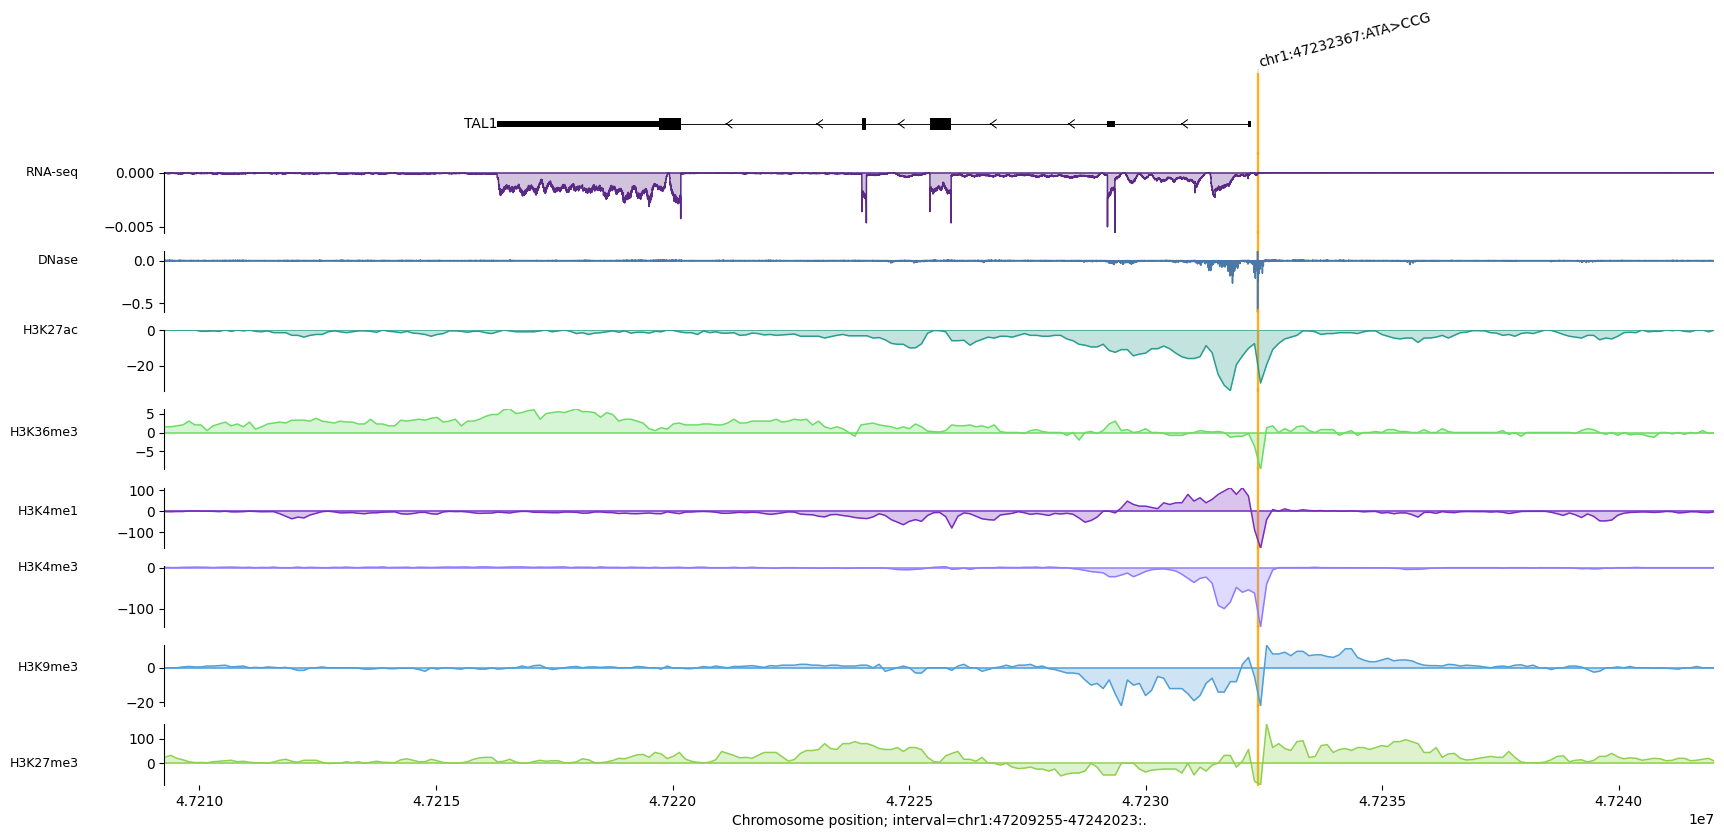

In [41]:
# BB: TAL1 33 kb, fixed labels on zero line of the correct tracks

import numpy as np
import pandas as pd
import matplotlib.transforms as mtransforms
from alphagenome.data.track_data import TrackData

tal1_interval_33kb = genome.Interval(
    chromosome='chr1',
    start=47209255,
    end=47242023,
    strand='.'
)

transcripts_33kb = transcript_extractor.extract(tal1_interval_33kb)

# --- delta tracks (ALT - REF) ---
delta_rna = delta_track(
    variant_output_multi.reference.rna_seq,
    variant_output_multi.alternate.rna_seq
)

delta_dnase = delta_track(
    variant_output_multi.reference.dnase,
    variant_output_multi.alternate.dnase
)

delta_chip_histone = delta_track(
    variant_output_multi.reference.chip_histone,
    variant_output_multi.alternate.chip_histone
)

# --- helpers ---
def _metadata_df(track):
    md = track.metadata
    if isinstance(md, pd.DataFrame):
        return md.reset_index(drop=True)
    return pd.DataFrame(md).reset_index(drop=True)

def _values_2d(track):
    vals = np.asarray(track.values)
    if vals.ndim == 1:
        vals = vals[:, None]
    return vals

def collapse_track(track, label):
    vals = _values_2d(track)
    md = pd.DataFrame({'name': [label], 'strand': ['.']})
    return TrackData(
        values=vals.mean(axis=1, keepdims=True),
        metadata=md,
        interval=track.interval,
        resolution=track.resolution
    )

def pick_histone(track, mark_name):
    vals = _values_2d(track)
    md = _metadata_df(track)

    row_text = md.astype(str).agg(' '.join, axis=1)
    idx = np.where(row_text.str.contains(mark_name, case=False, regex=False))[0]

    if len(idx) == 0:
        raise ValueError(f'Histone mark not found: {mark_name}')

    picked_vals = vals[:, idx].mean(axis=1, keepdims=True)
    picked_md = pd.DataFrame({'name': [mark_name], 'strand': ['.']})

    return TrackData(
        values=picked_vals,
        metadata=picked_md,
        interval=track.interval,
        resolution=track.resolution
    )

# --- build tracks in desired order ---
track_rna      = collapse_track(delta_rna, 'RNA-seq')
track_dnase    = collapse_track(delta_dnase, 'DNase')
track_h3k27ac  = pick_histone(delta_chip_histone, 'H3K27ac')
track_h3k36me3 = pick_histone(delta_chip_histone, 'H3K36me3')
track_h3k4me1  = pick_histone(delta_chip_histone, 'H3K4me1')
track_h3k4me3  = pick_histone(delta_chip_histone, 'H3K4me3')
track_h3k9me3  = pick_histone(delta_chip_histone, 'H3K9me3')
track_h3k27me3 = pick_histone(delta_chip_histone, 'H3K27me3')

ordered_tracks = [
    track_rna,
    track_dnase,
    track_h3k27ac,
    track_h3k36me3,
    track_h3k4me1,
    track_h3k4me3,
    track_h3k9me3,
    track_h3k27me3,
]

labels = [
    'RNA-seq',
    'DNase',
    'H3K27ac',
    'H3K36me3',
    'H3K4me1',
    'H3K4me3',
    'H3K9me3',
    'H3K27me3',
]

colors = [
    '#5b2a86',  # RNA-seq
    '#4c78a8',  # DNase
    '#2a9d8f',  # H3K27ac
    '#6bdc65',  # H3K36me3
    '#7b2cbf',  # H3K4me1
    '#8e7dff',  # H3K4me3
    '#4f9ed8',  # H3K9me3
    '#8fd14f',  # H3K27me3
]

fig = plot_components.plot(
    [plot_components.TranscriptAnnotation(transcripts_33kb, fig_height=0.1)] +
    [plot_components.Tracks(t) for t in ordered_tracks],
    interval=tal1_interval_33kb,
    annotations=[plot_components.VariantAnnotation([variant], alpha=0.8)],
)

# all automatic y-labels off
for ax in fig.axes:
    ax.set_ylabel('')

# robust: use the LAST 8 axes as the signal tracks
signal_axes = fig.axes[-8:]

for ax, label, color in zip(signal_axes, labels, colors):
    ax.axhline(0, color='lightgrey', linewidth=0.8, zorder=0)

    for line in ax.lines:
        x = np.asarray(line.get_xdata())
        y = np.asarray(line.get_ydata())

        line.set_color(color)
        line.set_linewidth(1.1)

        ax.fill_between(
            x, 0, y,
            color=color,
            alpha=0.28,
            linewidth=0,
            zorder=line.get_zorder() - 1
        )

    # place label exactly on the zero line of this axis
    trans = mtransforms.blended_transform_factory(ax.transAxes, ax.transData)
    ax.text(
        -0.055, 0, label,
        transform=trans,
        ha='right',
        va='center',
        fontsize=9,
        color='black',
        clip_on=False
    )

plt.savefig(
    '/content/tal1_fig6b_mutGATA_33kb_labelsfixed_v2.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()


We see that the ALT allele (base 'C' at position 36201698) is associated with
both lower expression and an exon skipping event in the *APOL4* gene on the
negative strand. Note that we can ignore the uppermost line plot which shows a
very minimal predicted amount of expression on the positive DNA strand (check
the y axis scales). It is possible to adjust the y axes limits, see
[visualization basics](https://www.alphagenomedocs.com/visualization_library_basics.html#visualization-library-basics)
and
[library documentation](https://www.alphagenomedocs.com/api/visualization.html).

## Scoring the effect of a genetic variant

Scoring the effect of a genetic variant involves making predictions for the REF
and ALT sequences and aggregating the track signal. This is implemented in
`score_variant`, which uses specific `variant_scorer` configs for aggregation.

We provide a set of recommended variant scoring configurations as a dictionary
(`variant_scorers.RECOMMENDED_VARIANT_SCORERS`), covering all output types,
which we have assessed for their performance at domain-specific tasks. See the
[variant scoring documentation](https://www.alphagenomedocs.com/variant_scoring.html)
for more information. Here is a quick demo:

In [ ]:
variant_scorer = variant_scorers.RECOMMENDED_VARIANT_SCORERS['RNA_SEQ']

variant_scores = dna_model.score_variant(
    interval=interval, variant=variant, variant_scorers=[variant_scorer]
)

The returned `variant_scores` is a list of length 1 because we only specified 1
scorer:

In [ ]:
len(variant_scores)

1

The actual scores per variant are in `AnnData` format, which is a way of
annotating data (the numerical scores) with additional information about the
rows and columns.

In [ ]:
variant_scores = variant_scores[0]
variant_scores

AnnData object with n_obs × n_vars = 32 × 667
    obs: 'gene_id', 'strand', 'gene_name', 'gene_type'
    var: 'name', 'strand', 'Assay title', 'ontology_curie', 'biosample_name', 'biosample_type', 'biosample_life_stage', 'gtex_tissue', 'data_source', 'endedness', 'genetically_modified', 'nonzero_mean'
    uns: 'interval', 'variant', 'variant_scorer'
    layers: 'quantiles'

`AnnData` objects have the following components:

<a href="https://services.google.com/fh/files/misc/anndata.png"><img src="https://services.google.com/fh/files/misc/anndata.png" alt="anndata" border="0" height=500></a>

We have a variant effect score for each of the 37 genes in the interval and each
of the 667 `RNA_SEQ` tracks:

In [ ]:
variant_scores.X.shape

(32, 667)

We can access information on the 37 genes using `.obs`. Here are just first 5
genes:

In [ ]:
variant_scores.obs.head()

,gene_id,strand,gene_name,gene_type
0,ENSG00000123473.17,-,STIL,protein_coding
1,ENSG00000142973.16,+,CYP4B1,protein_coding
2,ENSG00000154198.15,-,CYP4Z2P,transcribed_unprocessed_pseudogene
3,ENSG00000159658.15,-,EFCAB14,protein_coding
4,ENSG00000162365.13,+,CYP4A22,protein_coding


Note that if you are using a variant scorer that is not gene-specific (i.e., a
`variant_scorers.CenterMaskScorer`), then `variant_scores.X` would have shape
`(1, 667)` and there will be no gene metadata available since there is no
concept of genes in this scenario.

The description of each track is accessed using `.var` (this is the same
dataframe as the output metadata, but is included alongside the variant scores
for convenience):

In [ ]:
variant_scores.var

,name,strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,nonzero_mean
0,CL:0000047 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,0.143617
1,CL:0000062 total RNA-seq,+,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode,paired,False,0.094144
2,CL:0000084 polyA plus RNA-seq,+,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,0.124296
3,CL:0000084 total RNA-seq,+,total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,0.100934
4,CL:0000115 total RNA-seq,+,total RNA-seq,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode,single,False,0.135553
...,...,...,...,...,...,...,...,...,...,...,...,...
662,UBERON:0018115 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018115,left renal pelvis,tissue,embryonic,,encode,single,False,0.268222
663,UBERON:0018116 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018116,right renal pelvis,tissue,embryonic,,encode,single,False,0.258522
664,UBERON:0018117 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018117,left renal cortex interstitium,tissue,embryonic,,encode,single,False,0.215190
665,UBERON:0018118 polyA plus RNA-seq,.,polyA plus RNA-seq,UBERON:0018118,right renal cortex interstitium,tissue,embryonic,,encode,single,False,0.365676


Some handy additional metadata can be found in `.uns`:

In [ ]:
print(f'Interval: {variant_scores.uns["interval"]}')
print(f'Variant: {variant_scores.uns["variant"]}')
print(f'Variant scorer: {variant_scores.uns["variant_scorer"]}')

Interval: chr1:46715008-47763584:.
Variant: chr1:47239296:C>ACG
Variant scorer: GeneMaskLFCScorer(requested_output=RNA_SEQ)


We recommend interacting with variant scores by flattening `AnnData` objects
using `tidy_scores`, which produces a dataframe with each row being a single
score for each combination of (variant, gene, scorer, ontology). It optionally
excludes stranded tracks which do not match the gene’s strand for gene-specific
scorer.

The `raw_score` column contains the same values as stored in `variant_scores.X`.
The `quantile_score` column is the rank of the `raw_score` in the distribution
of scores for a background set of common variants, represented as a quantile
probability. This allows for direct comparison across variant scoring strategies
that yield scores on different scales. See
[FAQs](https://www.alphagenomedocs.com/faqs.html#what-is-the-difference-between-a-quantile-score-and-raw-score)
for further details.

In [ ]:

variant_scorers.tidy_scores([variant_scores], match_gene_strand=True)

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,endedness,genetically_modified,raw_score,quantile_score
0,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000123473,STIL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,paired,False,-0.014328,-0.998399
1,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000123473,STIL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,CL:0000062,osteoblast,primary_cell,adult,,encode,paired,False,-0.066383,-0.999882
2,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000123473,STIL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,CL:0000084,T-cell,primary_cell,adult,,encode,paired,False,-0.001975,-0.811199
3,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000123473,STIL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,CL:0000084,T-cell,primary_cell,adult,,encode,single,False,0.005373,0.977498
4,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000123473,STIL,protein_coding,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,CL:0000115,endothelial cell,in_vitro_differentiated_cells,adult,,encode,single,False,-0.044303,-0.999716
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12667,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000290456,CYP4Z2P,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,UBERON:0018115,left renal pelvis,tissue,embryonic,,encode,single,False,-0.000884,-0.576732
12668,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000290456,CYP4Z2P,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,UBERON:0018116,right renal pelvis,tissue,embryonic,,encode,single,False,-0.001426,-0.716204
12669,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000290456,CYP4Z2P,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,UBERON:0018117,left renal cortex interstitium,tissue,embryonic,,encode,single,False,-0.001680,-0.763115
12670,chr1:47239296:C>ACG,chr1:46715008-47763584:.,ENSG00000290456,CYP4Z2P,lncRNA,-,None,None,RNA_SEQ,GeneMaskLFCScorer(requested_output=RNA_SEQ),...,UBERON:0018118,right renal cortex interstitium,tissue,embryonic,,encode,single,False,-0.001934,-0.799028


## Highlighting important regions with *in silico* mutagenesis

To highlight which regions in a DNA sequence are functionally important for a
final variant prediction, we can perform an **in silico mutagenesis** (ISM)
analysis by scoring all possible single nucleotide variants in a specific
interval.

Here is a visual overview of this process:

<a href="https://services.google.com/fh/files/misc/ism_green_v2.png"><img src="https://services.google.com/fh/files/misc/ism_green_v2.png" alt="ISM" border="0" height=500></a>

We define an `ism_interval`, which is a relatively small region of DNA that we
want to systematically mutate. We also define the `sequence_interval`, which is
the contextual interval the model will use when making predictions for each
variant.

In [ ]:
# 16KB DNA sequence to use as context when making predictions.
sequence_interval = genome.Interval('chr20', 3_753_000, 3_753_400)
sequence_interval = sequence_interval.resize(dna_client.SEQUENCE_LENGTH_16KB)

# Mutate all bases in the central 256-base region of the sequence_interval.
ism_interval = sequence_interval.resize(256)

Next, we define the scorer we want to use to score each of the ISM variants.
Here, we use a center mask scorer on predicted `DNASE` values, which will score
each variant's effect on DNA accessibility in the 500bp vicinity. See the
[variant scoring documentation](https://www.alphagenomedocs.com/variant_scoring.html)
for more information on variant scoring.

In [ ]:
dnase_variant_scorer = variant_scorers.CenterMaskScorer(
    requested_output=dna_client.OutputType.DNASE,
    width=501,
    aggregation_type=variant_scorers.AggregationType.DIFF_MEAN,
)

Finally, we can use `score_variants` (notice the plural s) to score all
variants.

Note that this operation is quite expensive. For speed reasons, we recommend
using shorter input sequences for the contextual `sequence_interval` and
narrower `ism_interval` regions to mutate if possible.

In [ ]:
variant_scores = dna_model.score_ism_variants(
    interval=sequence_interval,
    ism_interval=ism_interval,
    variant_scorers=[dnase_variant_scorer],
)

The length of the returned `variant_scores` is 768, since we scored 768 variants
(256 positions * 3 alternative bases per position):

In [ ]:
len(variant_scores)

Each variant has scores of shape `(1, 305)`, reflecting the fact that we are not
using a gene-centric scorer and that there are 305 `DNASE` tracks:

In [ ]:
# Index into first variant and first scorer.
variant_scores[0][0].X.shape

To understand which positions are most influential in the predictions, we can
visualize these scores using a sequence logo. This requires summarizing the
scores into a single scalar value per variant.

As an example, let's extract the DNASE score for just the K562 cell line, a
widely used experimental model. Alternatively, you could average across multiple
tissues to obtain a single scalar value.

In [ ]:
def extract_k562(adata):
  values = adata.X[:, adata.var['ontology_curie'] == 'EFO:0002067']
  assert values.size == 1
  return values.flatten()[0]


ism_result = ism.ism_matrix(
    [extract_k562(x[0]) for x in variant_scores],
    variants=[v[0].uns['variant'] for v in variant_scores],
)

The shape of `ism_result` is `(256, 4`) since we have 1 score per position per
each of the 4 DNA bases.

Note that in this case, our call to `ism.ism_matrix()` had the argument
`multiply_by_sequence` set to 'True', so the output array contains non-zero
values only for the bases corresponding to the reference sequence.

In [ ]:
ism_result.shape

Finally, we plot the contribution scores as a sequence logo:

In [ ]:
plot_components.plot(
    [
        plot_components.SeqLogo(
            scores=ism_result,
            scores_interval=ism_interval,
            ylabel='ISM K562 DNase',
        )
    ],
    interval=ism_interval,
    fig_width=35,
)

plt.show()

This plot shows that the sequence between positions ~225 to ~240 has the
strongest effect on predicted nearby DNAse in K562 cells.

These contribution scores can be used to systematically discover motifs
important for different modalities and cell types, find the transcription
factors binding those motifs and map motif instances across the genome. Here are
a few tools you can use to do this: -
[tfmodisco-lite](https://github.com/jmschrei/tfmodisco-lite/) -
[tangermeme](https://github.com/jmschrei/tangermeme) -
[tomtom](https://meme-suite.org/meme/tools/tomtom)

## Making mouse predictions

So far, this notebook has focused on predictions for human
(`Organism.HOMO_SAPIENS`). To generate predictions for mouse, specify the
organism as `Organism.MUS_MUSCULUS` instead. Please note that the supported
ontology terms differ between species.

The following example demonstrates how to call `predict_sequence` for mouse
predictions:

In [ ]:
output = dna_model.predict_sequence(
    sequence='GATTACA'.center(
        dna_client.SEQUENCE_LENGTH_1MB, 'N'
    ),  # Pad to valid sequence length.
    organism=dna_client.Organism.MUS_MUSCULUS,
    requested_outputs=[dna_client.OutputType.DNASE],
    ontology_terms=['UBERON:0002048'],  # Lung.
)

And here is an example of calling `predict_interval` for a mouse genomic
interval:

In [ ]:
interval = genome.Interval('chr1', 3_000_000, 3_000_001).resize(
    dna_client.SEQUENCE_LENGTH_1MB
)

output = dna_model.predict_interval(
    interval=interval,
    organism=dna_client.Organism.MUS_MUSCULUS,
    requested_outputs=[dna_client.OutputType.RNA_SEQ],
    ontology_terms=['UBERON:0002048'],  # Lung.
)

output.rna_seq.values.shape

## Conclusion

That's it for the quick start guide. To dive in further, check out our
[other tutorials](https://www.alphagenomedocs.com/tutorials/index.html).